# eDNA Metabarcoding Pipeline Analysis: Lake Geneva (eKOI Database)
### A Reproducible Workflow for MinION Amplicon Sequencing (18S & COI)
**Project:** Genorobotics Semester Project (EPFL)

**Markers:** 18S rRNA (SILVA) & COI (eKOI PR2)

---

## 0. Critical Review: Database Changes

### COI: eKOI PR2 replaces MIDORI2
The COI marker now uses the **eKOI PR2 database** (15,947 sequences) instead of MIDORI2 (2.2M+ sequences).
* **Broader eukaryotic coverage:** eKOI includes protists, fungi, diatoms, and plants — not just metazoans.
* **PR2 taxonomy:** Clean 9-level hierarchy without NCBI taxon ID artifacts.
* **Smaller database:** 66MB vs 9.4GB — dramatically faster SINTAX queries.
* **Trade-off:** Fewer reference sequences means potentially lower species-level resolution for metazoans.

### 18S: SILVA unchanged
The 18S marker continues to use the SILVA v123 database.

### eKOI Taxonomy Mapping
| SINTAX level | PR2 field | Example |
|---|---|---|
| `d:` Domain | Kingdom | Eukaryota |
| `k:` Kingdom | Supergroup | Obazoa, TSAR, Archaeplastida |
| `p:` Phylum | Division | Opisthokonta, Alveolata |
| `c:` Class | Subdivision | Metazoa, Fungi, Apicomplexa |
| `o:` Order | Class | Insecta, Teleostei |
| `f:` Family | Family | resolved from Order/Family |
| `g:` Genus | Genus | Daphnia |
| `s:` Species | Species | Daphnia_galeata |

### Key Question: Does eKOI improve COI ciliate classification?
The previous MIDORI2 analysis showed that ciliates dominated the COI signal but were poorly classified. eKOI's protist coverage should help identify these organisms more accurately.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from pathlib import Path
from Bio import SeqIO
from matplotlib import cm

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

def clean_sample_names(columns):
    return [c.replace('Sample_barcode', '').replace('Sample_', '') for c in columns]

def get_tax_prefix(df):
    for col in df.columns:
        if col.startswith("SILVA_"):
            return "SILVA"
        if col.startswith("MIDORI2_"):
            return "MIDORI2"
        if col.startswith("MIDORI_"):
            return "MIDORI"
        if col.startswith("eKOI_"):
            return "eKOI"
    return "SILVA"

BASE = Path("out/Water_eDNA_18S_COI_14_01_26")

# Global confidence threshold for taxonomy filtering
CONF_THRESHOLD = 0.8

def stacked_bar_compare(df, rank, prefix, marker_label, sample_cols, top_n=10, conf_threshold=None):
    """Two side-by-side stacked bars: left includes Unassigned, right excludes it.

    - Blanks low-confidence assignments (< conf_threshold) before grouping.
    - Keeps Unassigned in the data so it\'s visible in the left panel with
      a dedicated gray color + legend entry.
    - Right panel drops Unassigned and renormalizes to 100% of assigned reads,
      useful when Unassigned dominates (e.g. soil COI).
    """
    if conf_threshold is None:
        conf_threshold = CONF_THRESHOLD
    col = f'{prefix}_{rank}'
    conf_col = f'{prefix}_{rank}_Conf'
    d = df.copy()
    if conf_col in d.columns:
        d.loc[pd.to_numeric(d[conf_col], errors='coerce').fillna(0) < conf_threshold, col] = ''
    d[col] = d[col].replace('', 'Unassigned').fillna('Unassigned')
    grouped = d.groupby(col)[sample_cols].sum()

    unassigned_row = grouped.loc['Unassigned'] if 'Unassigned' in grouped.index else None
    assigned = grouped.drop('Unassigned', errors='ignore').copy()
    assigned['Total'] = assigned.sum(axis=1)
    assigned = assigned.sort_values('Total', ascending=False)
    top_idx = assigned.head(top_n).index
    top_data = assigned.loc[top_idx].drop(columns='Total')
    others_data = assigned.loc[~assigned.index.isin(top_idx)].drop(columns='Total').sum()

    # Build LEFT (with Unassigned) and RIGHT (without)
    left = top_data.copy()
    left.loc['Others'] = others_data
    if unassigned_row is not None:
        left.loc['Unassigned'] = unassigned_row
    left_pct = left.div(left.sum(axis=0).replace(0, np.nan), axis=1) * 100
    left_pct = left_pct.fillna(0)

    right = top_data.copy()
    right.loc['Others'] = others_data
    right_pct = right.div(right.sum(axis=0).replace(0, np.nan), axis=1) * 100
    right_pct = right_pct.fillna(0)

    def colors_for(data_):
        palette = cm.tab20(np.linspace(0, 1, max(len(data_) - 2, 1)))
        out = []
        pi = 0
        for name in data_.index:
            if name == 'Unassigned':
                out.append('#D3D3D3')
            elif name == 'Others':
                out.append('#696969')
            else:
                out.append(palette[pi % len(palette)])
                pi += 1
        return out

    # Report Unassigned share for context
    if unassigned_row is not None:
        total_reads = grouped.sum().sum()
        un_share = 100 * unassigned_row.sum() / total_reads if total_reads else 0
        print(f'[{marker_label}] {rank}: Unassigned = {un_share:.1f}% of reads')

    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    for ax, data, subtitle in [(axes[0], left_pct, 'including Unassigned'),
                                (axes[1], right_pct, 'excluding Unassigned (renormalized)')]:
        data = data.copy()
        data.columns = clean_sample_names(data.columns)
        data.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=colors_for(data))
        ax.set_title(f'{rank}-Level Composition ({marker_label}, {prefix})\n{subtitle}',
                     fontweight='bold', fontsize=11)
        ax.set_ylabel('Relative Abundance (%)')
        ax.set_xlabel('Sample')
        h, l = ax.get_legend_handles_labels()
        ax.legend(reversed(h), reversed(l), bbox_to_anchor=(1.02, 1), loc='upper left',
                  title=rank, fontsize=8)
        for _i, _s in enumerate(data.columns):
            if data[_s].sum() == 0:
                ax.text(_i, 2, 'ND', ha='center', va='bottom', fontsize=9,
                        color='gray', fontstyle='italic')
        ax.set_ylim(0, 105)
    plt.tight_layout()
    add_conf_note(fig, 'filtered')
    plt.show()

# Confidence-interpretation caption helper
_CONF_NOTES = {
    'filtered':   'SINTAX confidence \u2265 0.8 applied \u2014 lower-confidence calls treated as Unassigned.',
    'unfiltered': 'No confidence filter applied \u2014 includes low-confidence assignments. Interpret taxa cautiously.',
    'blast':      'Based on BLAST vs NCBI identity (not SINTAX confidence).',
    'qc':         'Pre-taxonomy QC plot \u2014 confidence filter not applicable.',
    'meta':       'Pipeline metadata \u2014 confidence filter not applicable.',
}
def add_conf_note(fig=None, kind='filtered'):
    if fig is None:
        fig = plt.gcf()
    txt = _CONF_NOTES.get(kind, _CONF_NOTES['filtered'])
    fig.text(0.5, -0.02, txt, ha='center', va='top', fontsize=9,
             style='italic', color='#555555', wrap=True)


## Table Headers & Data Structure
Inspect the comprehensive taxonomy CSV files to verify column names and data shape.

In [2]:
df_18s = pd.read_csv(BASE / 'taxonomy_summary/silva-ekoi/comprehensive_taxonomy_18S.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/silva-ekoi/comprehensive_taxonomy_COI.csv')

prefix_18s = get_tax_prefix(df_18s)
prefix_coi = get_tax_prefix(df_coi_raw)

for label, df, pfx in [("18S", df_18s, prefix_18s), ("COI", df_coi_raw, prefix_coi)]:
    print(f"\n{'='*60}")
    print(f"  {label} ({pfx} database)  \u2014  {df.shape[0]} OTUs \u00d7 {df.shape[1]} columns")
    print(f"{'='*60}")
    
    sample_cols = [c for c in df.columns if c.startswith("Sample_")]
    taxonomy_cols = [c for c in df.columns if c.startswith(f"{pfx}_") or c.startswith("NCBI_")]
    meta_cols = [c for c in df.columns if c not in sample_cols + taxonomy_cols]
    
    print(f"\nMetadata columns:  {meta_cols}")
    print(f"Sample columns:    {sample_cols}")
    print(f"Taxonomy columns:  {taxonomy_cols}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))


  18S (SILVA database)  —  59002 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['SILVA_Domain', 'SILVA_Domain_Conf', 'SILVA_Phylum', 'SILVA_Phylum_Conf', 'SILVA_Class', 'SILVA_Class_Conf', 'SILVA_Order', 'SILVA_Order_Conf', 'SILVA_Family', 'SILVA_Family_Conf', 'SILVA_Genus', 'SILVA_Genus_Conf', 'SILVA_Species', 'SILVA_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,SILVA_Order_Conf,SILVA_Family,SILVA_Family_Conf,SILVA_Genus,SILVA_Genus_Conf,SILVA_Species,SILVA_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_18S_005421,0.766523,1,0.004390,0.095702,0.082278,0.099657,0.0,0.0,0.006094,...,1.00,Oligotrichia,1.0,Strombidium,1.00,uncultured_ciliate,0.76,NaN,NaN,NaN
1,OTU_18S_000035,0.355367,2,0.020870,0.021060,0.004128,0.006171,0.0,0.0,0.028086,...,0.13,NaN,NaN,Cleome,0.13,Tarenaya_hassleriana,0.13,NaN,NaN,NaN
2,OTU_18S_000362,0.310807,3,0.008224,0.016476,0.003853,0.005794,0.0,0.0,0.010984,...,0.14,NaN,NaN,Cleome,0.14,Tarenaya_hassleriana,0.14,NaN,NaN,NaN



  COI (eKOI database)  —  6281 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['eKOI_Domain', 'eKOI_Domain_Conf', 'eKOI_Phylum', 'eKOI_Phylum_Conf', 'eKOI_Class', 'eKOI_Class_Conf', 'eKOI_Order', 'eKOI_Order_Conf', 'eKOI_Family', 'eKOI_Family_Conf', 'eKOI_Genus', 'eKOI_Genus_Conf', 'eKOI_Species', 'eKOI_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,eKOI_Order_Conf,eKOI_Family,eKOI_Family_Conf,eKOI_Genus,eKOI_Genus_Conf,eKOI_Species,eKOI_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000076,0.279448,1,0.021097,0.040323,0.042105,0.008237,0.0,0.0,0.01108,...,0.24,Amphibia,0.06,Liua,0.03,Liua_tsinpaensis,0.03,NaN,NaN,NaN
1,OTU_COI_005155,0.166667,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,0.17,Amphibia,0.03,Onychodactylus,0.02,Onychodactylus_zhaoermii,0.02,NaN,NaN,NaN
2,OTU_COI_005391,0.166667,3,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Confidence Distribution Dashboard
Visualize the SINTAX bootstrap confidence for taxonomy assignments across ranks.
Only assignments with confidence >= 0.8 are stored in the CSV.

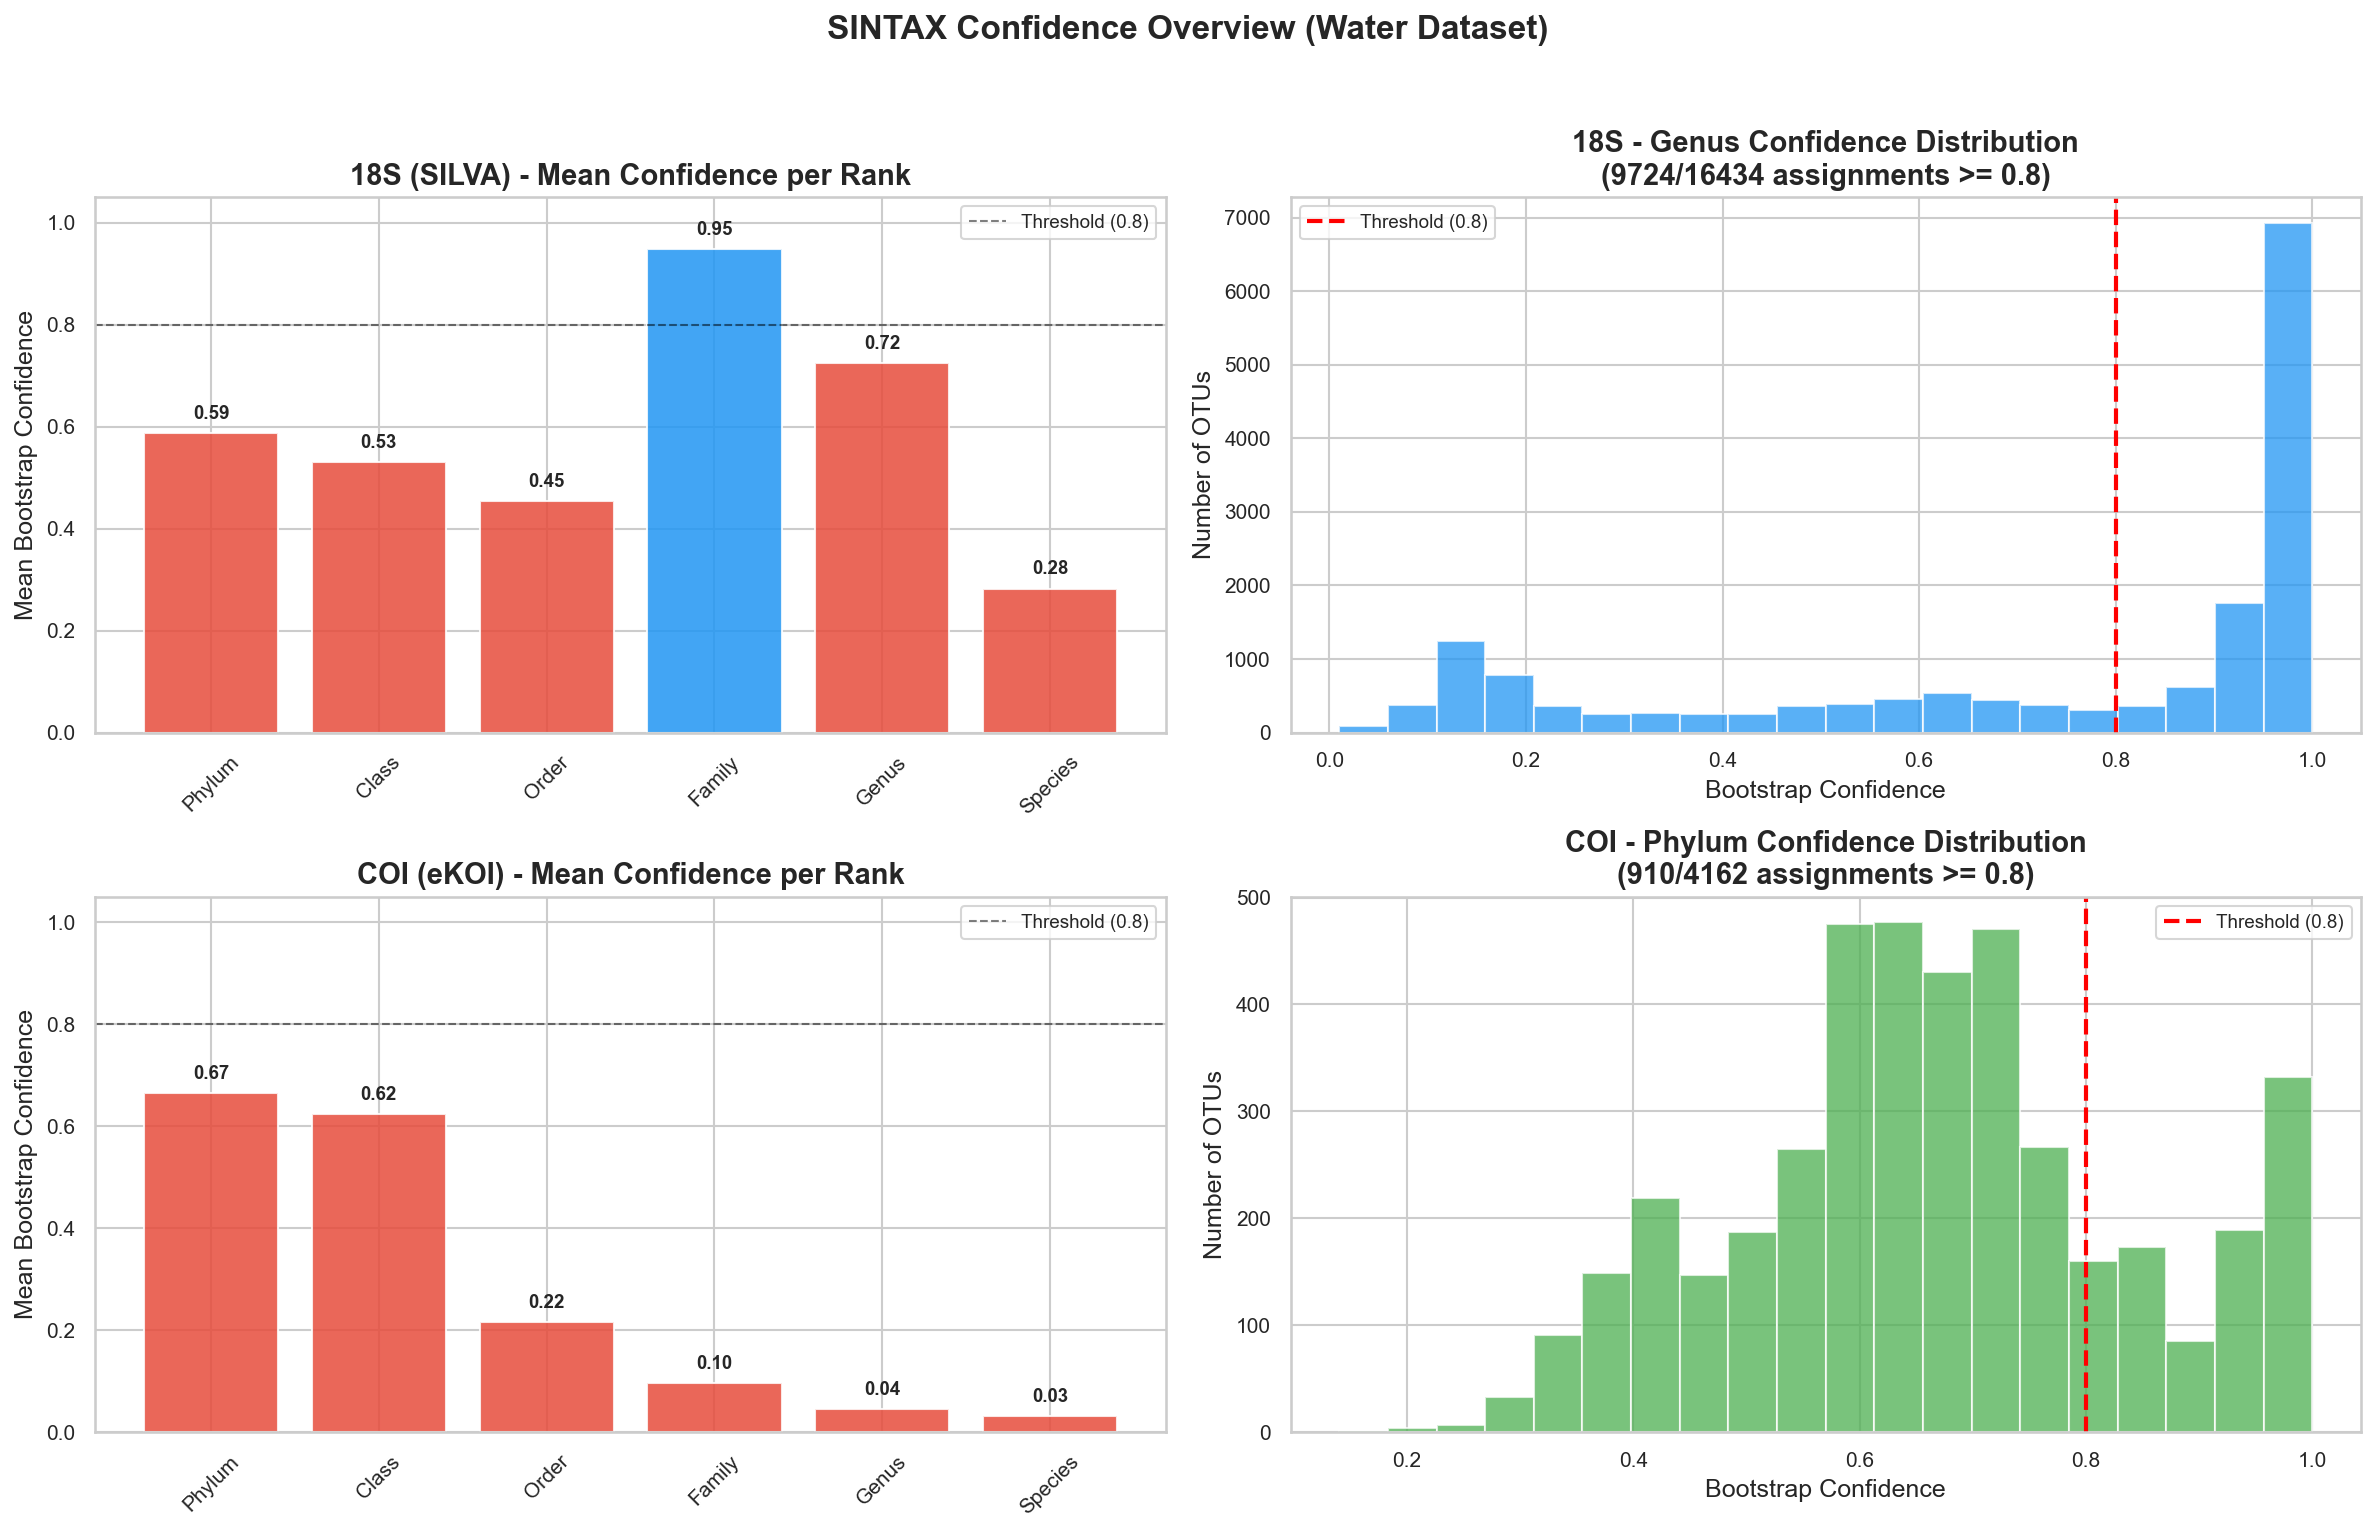

In [3]:
# Confidence Distribution Dashboard
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

marker_info = [
    ("18S", df_18s, prefix_18s, "#2196F3"),
    ("COI", df_coi_raw, prefix_coi, "#4CAF50"),
]

# Check if confidence columns exist
has_conf = any(c.endswith('_Conf') for c in df_18s.columns) or any(c.endswith('_Conf') for c in df_coi_raw.columns)

if not has_conf:
    print("No confidence columns found in CSV files.")
    print("Regenerate with: bash regenerate_taxonomy.sh")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for row, (marker, df, pfx, color) in enumerate(marker_info):
        # Left: Mean confidence per rank
        ax = axes[row, 0]
        mean_confs = []
        for rank in ranks:
            conf_col = f'{pfx}_{rank}_Conf'
            if conf_col in df.columns:
                vals = pd.to_numeric(df[conf_col], errors='coerce').dropna()
                mean_confs.append(vals.mean() if len(vals) > 0 else 0)
            else:
                mean_confs.append(0)
        
        bar_colors = [color if c >= 0.8 else '#e74c3c' for c in mean_confs]
        bars = ax.bar(ranks, mean_confs, color=bar_colors, alpha=0.85, edgecolor='white')
        ax.axhline(y=0.8, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Threshold (0.8)')
        ax.set_title(f'{marker} ({pfx}) - Mean Confidence per Rank', fontweight='bold')
        ax.set_ylabel('Mean Bootstrap Confidence')
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=45)
        for bar, val in zip(bars, mean_confs):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.legend(fontsize=9)
        
        # Right: Confidence histogram for best rank
        ax2 = axes[row, 1]
        hist_rank = 'Genus' if pfx == 'SILVA' else 'Phylum'
        conf_col = f'{pfx}_{hist_rank}_Conf'
        if conf_col in df.columns:
            vals = pd.to_numeric(df[conf_col], errors='coerce').dropna()
            if len(vals) > 0:
                ax2.hist(vals, bins=20, color=color, alpha=0.75, edgecolor='white')
                ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Threshold (0.8)')
                n_above = (vals >= 0.8).sum()
                ax2.set_title(f'{marker} - {hist_rank} Confidence Distribution\n'
                             f'({n_above}/{len(vals)} assignments >= 0.8)', fontweight='bold')
            else:
                ax2.set_title(f'{marker} - No {hist_rank} assignments', fontweight='bold')
        else:
            ax2.text(0.5, 0.5, f'No {conf_col} column', transform=ax2.transAxes, ha='center')
            ax2.set_title(f'{marker} - {hist_rank} Confidence', fontweight='bold')
        ax2.set_xlabel('Bootstrap Confidence')
        ax2.set_ylabel('Number of OTUs')
        ax2.legend(fontsize=9)
    
    plt.suptitle('SINTAX Confidence Overview (Water Dataset)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    add_conf_note(kind='filtered')
    plt.show()


## Database Performance Dashboard

Evaluate how well the reference database classifies our OTUs. Three diagnostic panels per marker:

1. **OTUs classified per rank** — What fraction of OTUs gets any assignment (gray) vs a *confident* assignment (green, ≥ 0.8) at each rank. Shows **coverage breadth + quality**.
2. **Reads covered per rank** — Same but weighted by read abundance. A DB could classify few OTUs that nonetheless represent most reads (or the opposite).
3. **Deepest confident rank** — For each OTU, the deepest rank it reached confidently. Shows the **resolution power** of the DB for this dataset.

Good DB for this marker = high green bars + reads-covered high + most OTUs reaching Genus/Species.

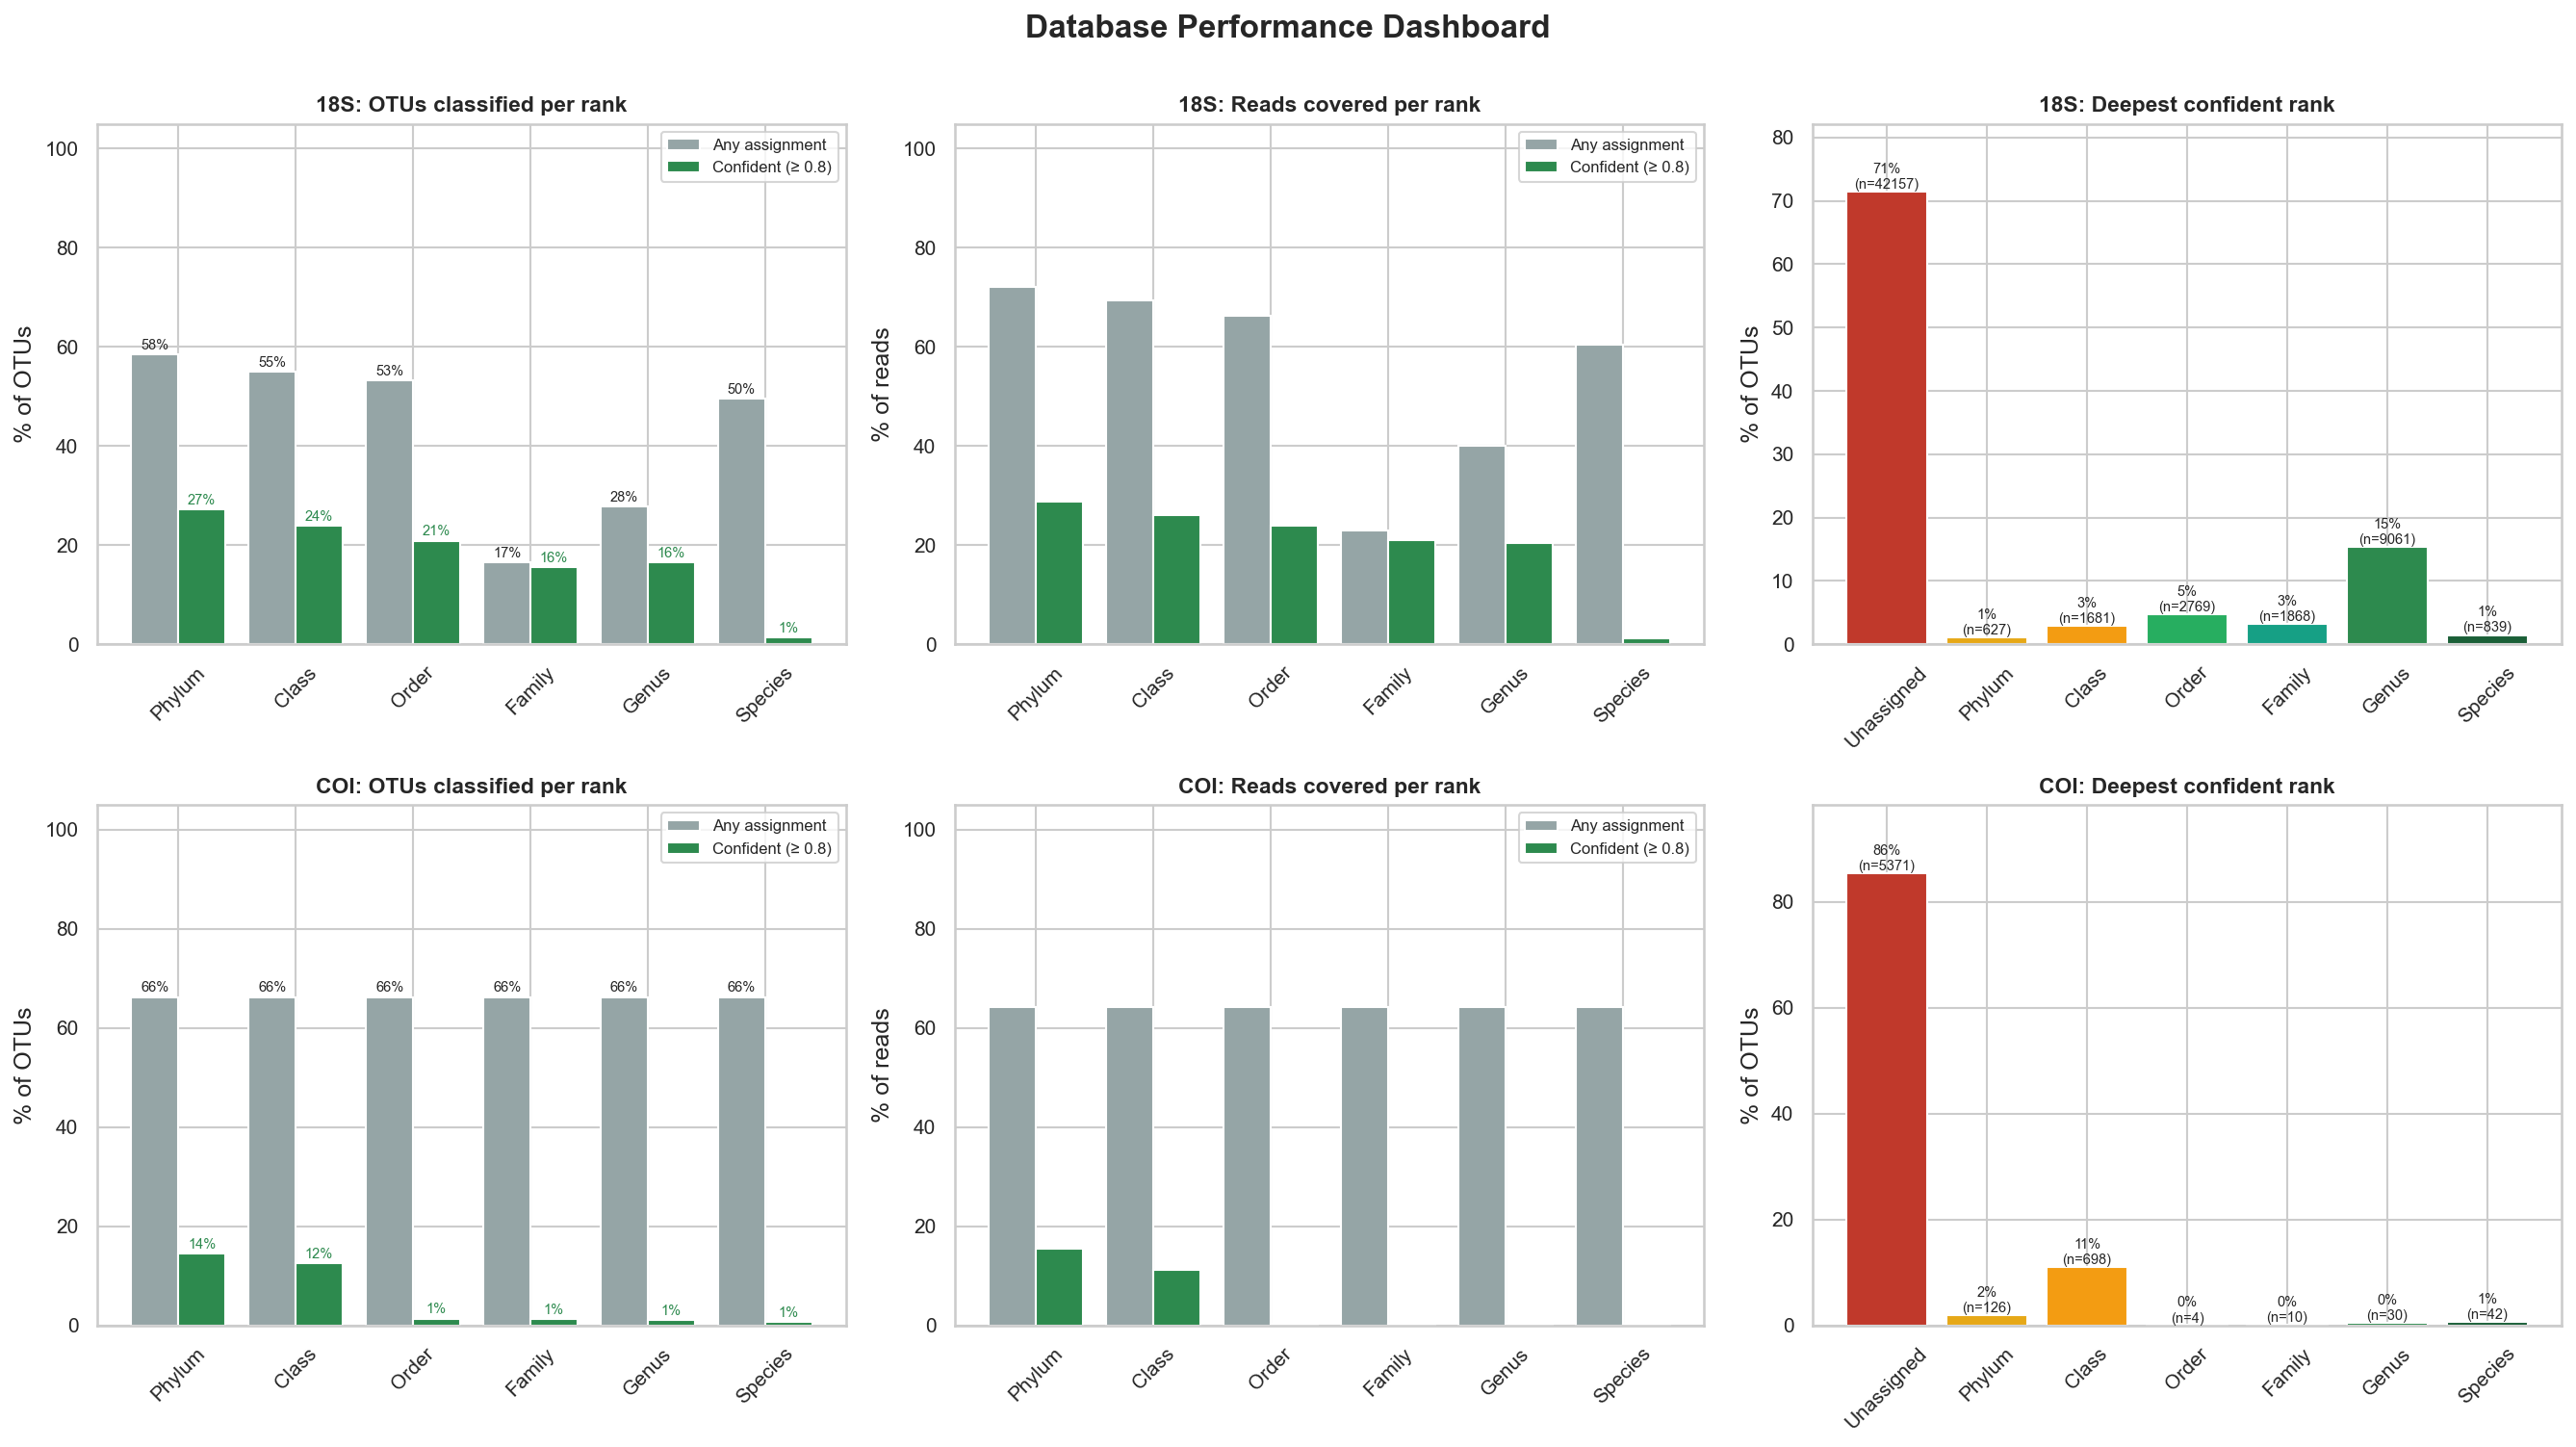


DATABASE PERFORMANCE SUMMARY

18S  (DB: SILVA)
  Rank         % OTUs any    % OTUs conf   % reads conf
  Phylum            58.4%          27.3%          28.8%
  Class             54.9%          23.8%          26.0%
  Order             53.2%          20.9%          23.9%
  Family            16.5%          15.6%          21.0%
  Genus             27.9%          16.5%          20.4%
  Species           49.6%           1.4%           1.3%

COI  (DB: eKOI)
  Rank         % OTUs any    % OTUs conf   % reads conf
  Phylum            66.3%          14.5%          15.4%
  Class             66.3%          12.5%          11.2%
  Order             66.3%           1.4%           0.4%
  Family            66.3%           1.3%           0.4%
  Genus             66.3%           1.1%           0.4%
  Species           66.3%           0.7%           0.2%


In [4]:
# Database Performance Dashboard
# Shows how well the reference DB classifies our OTUs: assignment rate per rank,
# confident-assignment rate, read-weighted coverage, and resolution depth.

ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
marker_data = [(df_18s, prefix_18s, '18S'), (df_coi_raw, prefix_coi, 'COI')]

def db_stats(df, prefix):
    """Return per-rank stats for a marker."""
    stats = {'rank': [], 'pct_any': [], 'pct_conf': [],
             'pct_reads_any': [], 'pct_reads_conf': []}
    total_otus = len(df)
    total_reads = df['Total_Abundance'].sum() if 'Total_Abundance' in df.columns else df[[c for c in df.columns if c.startswith('Sample_')]].sum().sum()
    for rank in ranks:
        col = f'{prefix}_{rank}'
        conf_col = f'{prefix}_{rank}_Conf'
        if col not in df.columns:
            continue
        has_any = ~df[col].isin(['Unassigned', '', None]) & df[col].notna()
        if conf_col in df.columns:
            conf_vals = pd.to_numeric(df[conf_col], errors='coerce').fillna(0)
            has_conf = has_any & (conf_vals >= CONF_THRESHOLD)
        else:
            has_conf = has_any
        reads_col = 'Total_Abundance' if 'Total_Abundance' in df.columns else None
        if reads_col:
            reads_any = df.loc[has_any, reads_col].sum()
            reads_conf = df.loc[has_conf, reads_col].sum()
        else:
            sample_cols = [c for c in df.columns if c.startswith('Sample_')]
            reads_any = df.loc[has_any, sample_cols].sum().sum()
            reads_conf = df.loc[has_conf, sample_cols].sum().sum()
        stats['rank'].append(rank)
        stats['pct_any'].append(100 * has_any.sum() / total_otus)
        stats['pct_conf'].append(100 * has_conf.sum() / total_otus)
        stats['pct_reads_any'].append(100 * reads_any / total_reads if total_reads > 0 else 0)
        stats['pct_reads_conf'].append(100 * reads_conf / total_reads if total_reads > 0 else 0)
    return stats

def resolution_depth(df, prefix):
    """For each OTU, find deepest confident rank. Returns counts per rank + Unassigned."""
    depths = {'Unassigned': 0}
    for r in ranks:
        depths[r] = 0
    for _, row in df.iterrows():
        deepest = 'Unassigned'
        for rank in ranks:
            col = f'{prefix}_{rank}'
            conf_col = f'{prefix}_{rank}_Conf'
            if col not in df.columns:
                continue
            val = row.get(col, '')
            if pd.isna(val) or val in ('Unassigned', ''):
                continue
            if conf_col in df.columns:
                try:
                    if float(row.get(conf_col, 0) or 0) >= CONF_THRESHOLD:
                        deepest = rank
                except (ValueError, TypeError):
                    pass
            else:
                deepest = rank
        depths[deepest] += 1
    return depths

# Build figure: one row per marker, 3 subplots per row
n_markers = len(marker_data)
fig, axes = plt.subplots(n_markers, 3, figsize=(18, 5 * n_markers))
if n_markers == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Database Performance Dashboard', fontsize=16, fontweight='bold', y=1.00)

for row_idx, (df, prefix, label) in enumerate(marker_data):
    s = db_stats(df, prefix)
    x = np.arange(len(s['rank']))
    width = 0.4

    # --- Panel 1: OTU-based assignment rate ---
    ax = axes[row_idx, 0]
    ax.bar(x - width/2, s['pct_any'], width, color='#95a5a6', label='Any assignment')
    ax.bar(x + width/2, s['pct_conf'], width, color='#2d8a4e', label=f'Confident (\u2265 {CONF_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(s['rank'], rotation=45)
    ax.set_ylabel('% of OTUs')
    ax.set_ylim(0, 105)
    ax.set_title(f'{label}: OTUs classified per rank', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    for xi, (a, c) in enumerate(zip(s['pct_any'], s['pct_conf'])):
        ax.text(xi - width/2, a + 1, f'{a:.0f}%', ha='center', fontsize=7)
        ax.text(xi + width/2, c + 1, f'{c:.0f}%', ha='center', fontsize=7, color='#2d8a4e')

    # --- Panel 2: Read-weighted assignment rate ---
    ax = axes[row_idx, 1]
    ax.bar(x - width/2, s['pct_reads_any'], width, color='#95a5a6', label='Any assignment')
    ax.bar(x + width/2, s['pct_reads_conf'], width, color='#2d8a4e', label=f'Confident (\u2265 {CONF_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(s['rank'], rotation=45)
    ax.set_ylabel('% of reads')
    ax.set_ylim(0, 105)
    ax.set_title(f'{label}: Reads covered per rank', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

    # --- Panel 3: Resolution depth ---
    ax = axes[row_idx, 2]
    depths = resolution_depth(df, prefix)
    labels_d = ['Unassigned'] + ranks
    counts_d = [depths.get(l, 0) for l in labels_d]
    total_d = sum(counts_d)
    pcts_d = [100 * c / total_d if total_d > 0 else 0 for c in counts_d]
    colors_d = ['#c0392b'] + ['#e6a817', '#f39c12', '#27ae60', '#16a085', '#2d8a4e', '#1a5f37']
    bars = ax.bar(labels_d, pcts_d, color=colors_d)
    ax.set_ylabel('% of OTUs')
    ax.set_ylim(0, max(pcts_d) * 1.15 if pcts_d else 100)
    ax.set_title(f'{label}: Deepest confident rank', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    for xi, (p, c) in enumerate(zip(pcts_d, counts_d)):
        ax.text(xi, p + 0.5, f'{p:.0f}%\n(n={c})', ha='center', fontsize=7)

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

# Print summary table
print("\n" + "=" * 70)
print("DATABASE PERFORMANCE SUMMARY")
print("=" * 70)
for df, prefix, label in marker_data:
    s = db_stats(df, prefix)
    print(f"\n{label}  (DB: {prefix})")
    print(f"  {'Rank':<10} {'% OTUs any':>12} {'% OTUs conf':>14} {'% reads conf':>14}")
    for i, r in enumerate(s['rank']):
        print(f"  {r:<10} {s['pct_any'][i]:>11.1f}% {s['pct_conf'][i]:>13.1f}% {s['pct_reads_conf'][i]:>13.1f}%")


## Raw Read Length Distributions (Pre-Clustering)

✓ 18S: 226,443 reads, median=1857bp, range=1500-2799bp
✓ COI: 14,495 reads, median=834bp, range=500-900bp


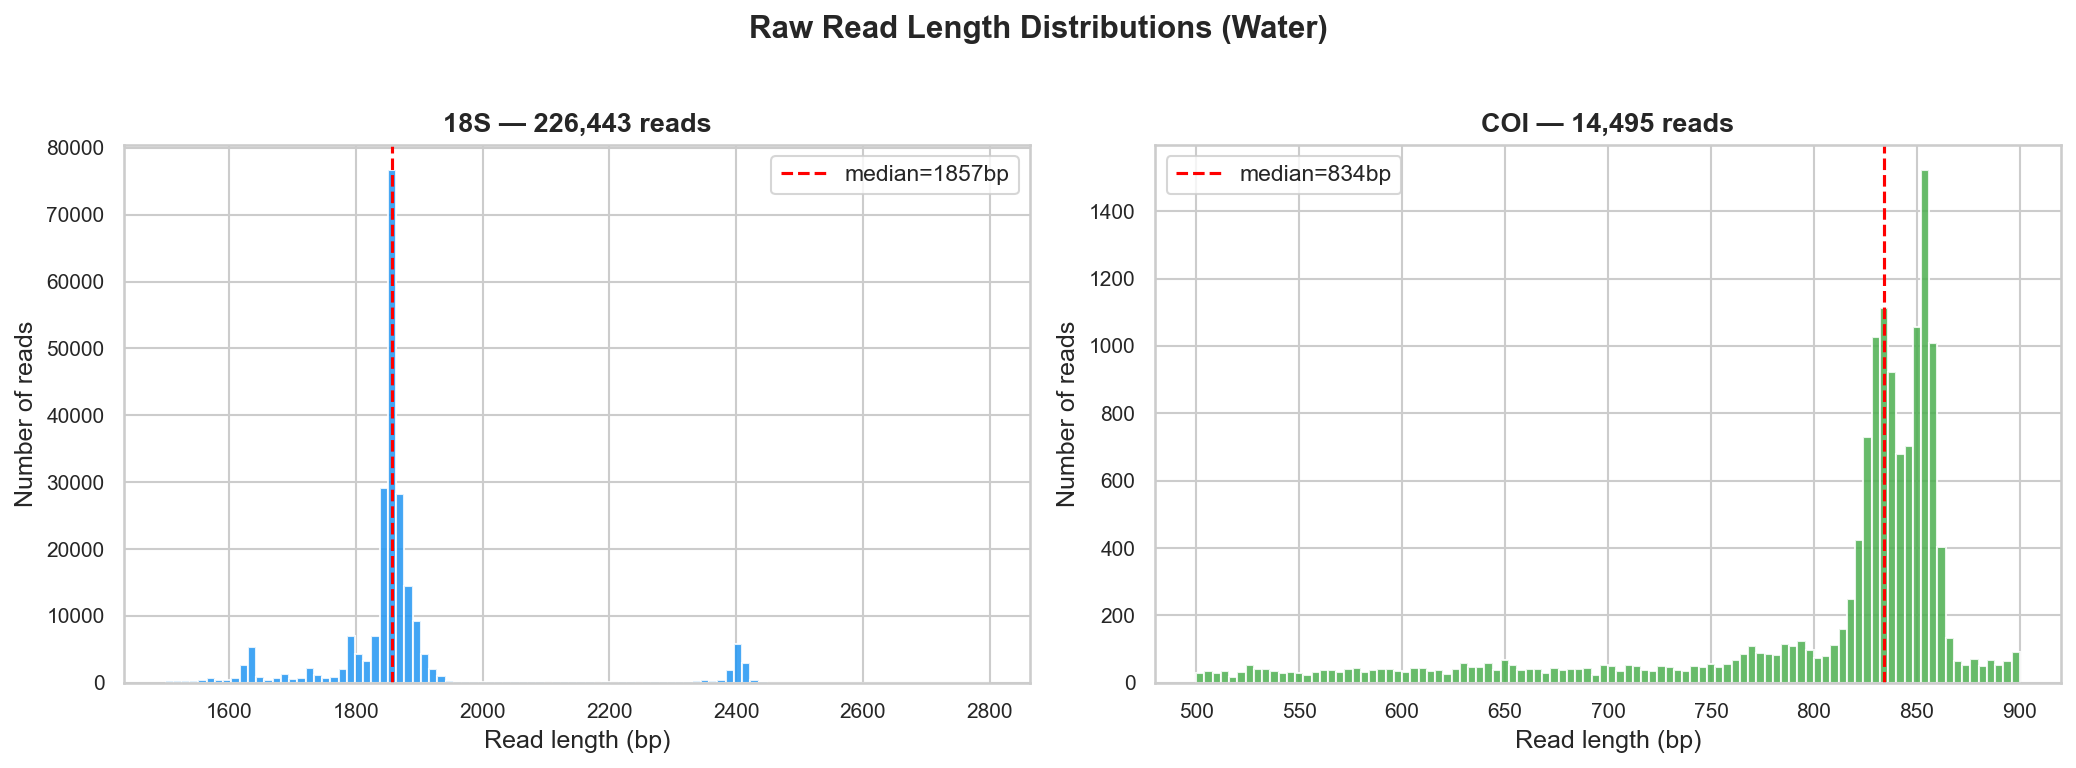

In [5]:
import gzip

barcode_dirs = sorted(BASE.glob("barcode*"))
marker_lengths = {"18S": [], "COI": []}
marker_colors_raw = {"18S": "#2196F3", "COI": "#4CAF50"}

for bd in barcode_dirs:
    for marker in marker_lengths:
        fq = bd / f"filtered_reads_{marker}.fastq.gz"
        if fq.exists():
            with gzip.open(str(fq), 'rt') as f:
                for i, line in enumerate(f):
                    if i % 4 == 1:
                        marker_lengths[marker].append(len(line.strip()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, lengths) in enumerate(marker_lengths.items()):
    ax = axes[i]
    if lengths:
        ax.hist(lengths, bins=100, color=marker_colors_raw[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} \u2014 {len(lengths):,} reads", fontsize=13, fontweight="bold")
        ax.set_xlabel("Read length (bp)")
        ax.set_ylabel("Number of reads")
        ax.legend()
        print(f"\u2713 {marker}: {len(lengths):,} reads, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nNo reads found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Raw Read Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
add_conf_note(kind='qc')
plt.show()

## Consensus OTU Sequence Length Distributions

✓ 18S: 35237 OTUs, median=1853bp, range=1500-2809bp
✓ COI: 4162 OTUs, median=829bp, range=417-902bp


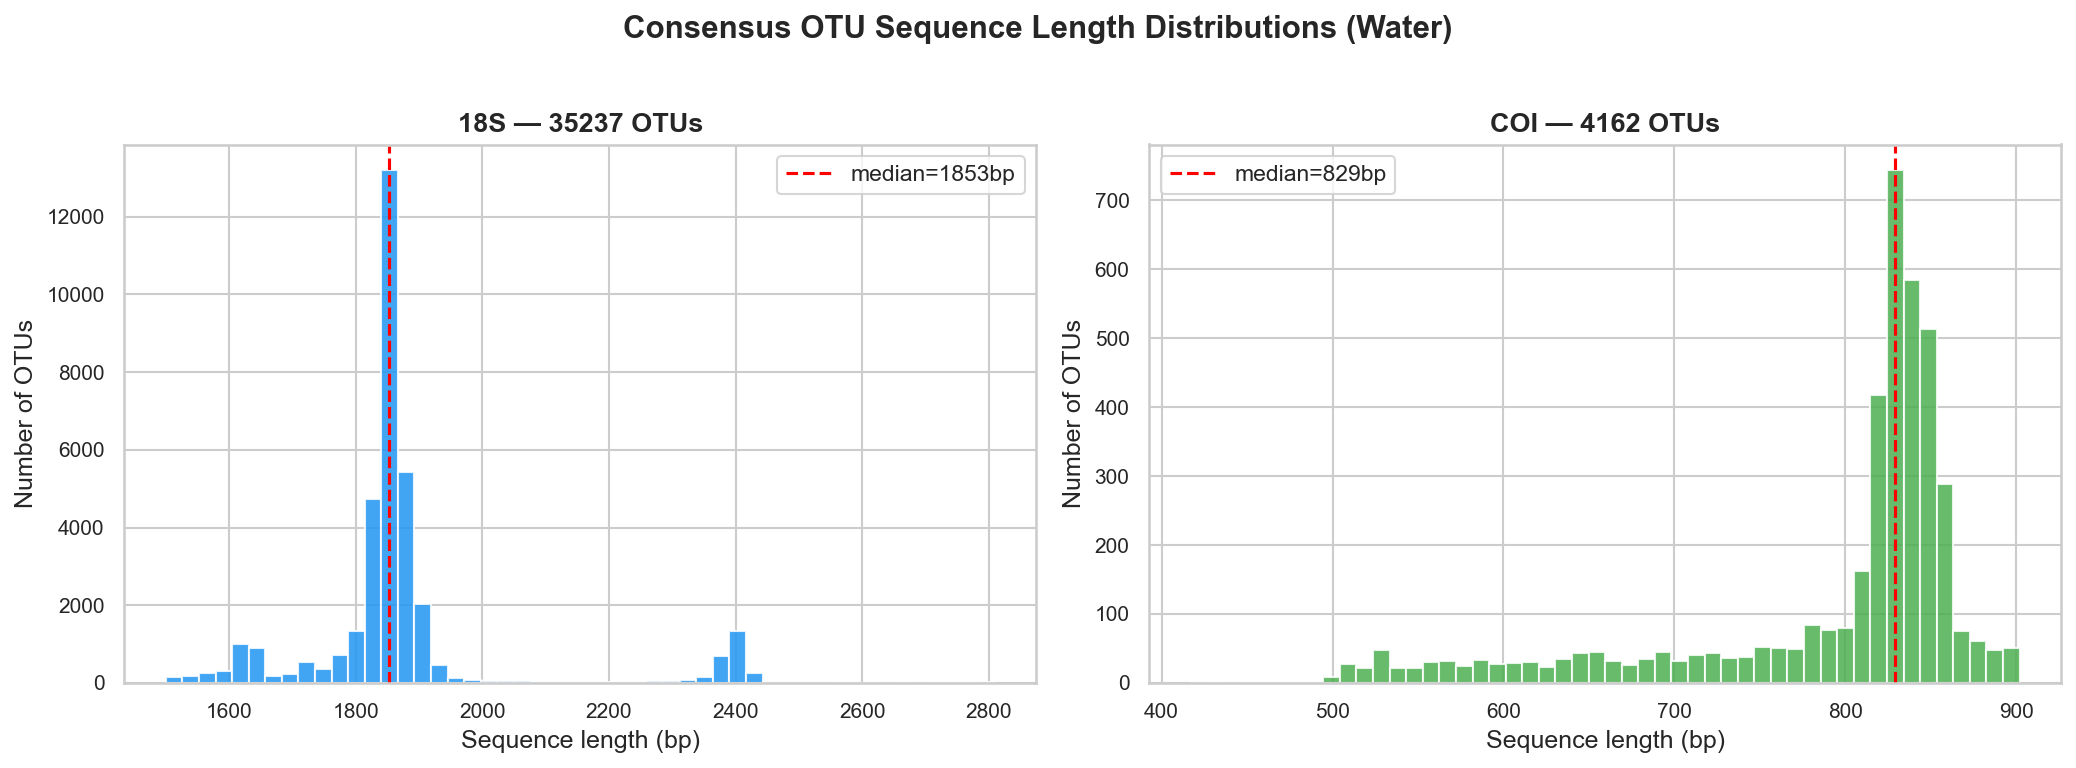

In [6]:
fasta_files = {
    "18S": BASE / "temp_clustering/consensus_18S_clean.fasta",
    "COI": BASE / "temp_clustering/consensus_COI_clean.fasta",
}
marker_colors = {"18S": "#2196F3", "COI": "#4CAF50"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, path) in enumerate(fasta_files.items()):
    ax = axes[i]
    if path.exists():
        lengths = [len(rec.seq) for rec in SeqIO.parse(str(path), "fasta")]
        ax.hist(lengths, bins=50, color=marker_colors[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} \u2014 {len(lengths)} OTUs", fontsize=13, fontweight="bold")
        ax.set_xlabel("Sequence length (bp)")
        ax.set_ylabel("Number of OTUs")
        ax.legend()
        print(f"\u2713 {marker}: {len(lengths)} OTUs, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nFASTA not found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Consensus OTU Sequence Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
add_conf_note(kind='qc')
plt.show()

---
# Part A: 18S Marker Biodiversity Analysis (SILVA)
*Objective: Characterize the planktonic community using the 18S marker. This section is unchanged from the MIDORI2 analysis since 18S still uses SILVA.*

## A.1a Broad Taxonomic Structure (18S)

[18S] Phylum: Unassigned = 71.6% of reads


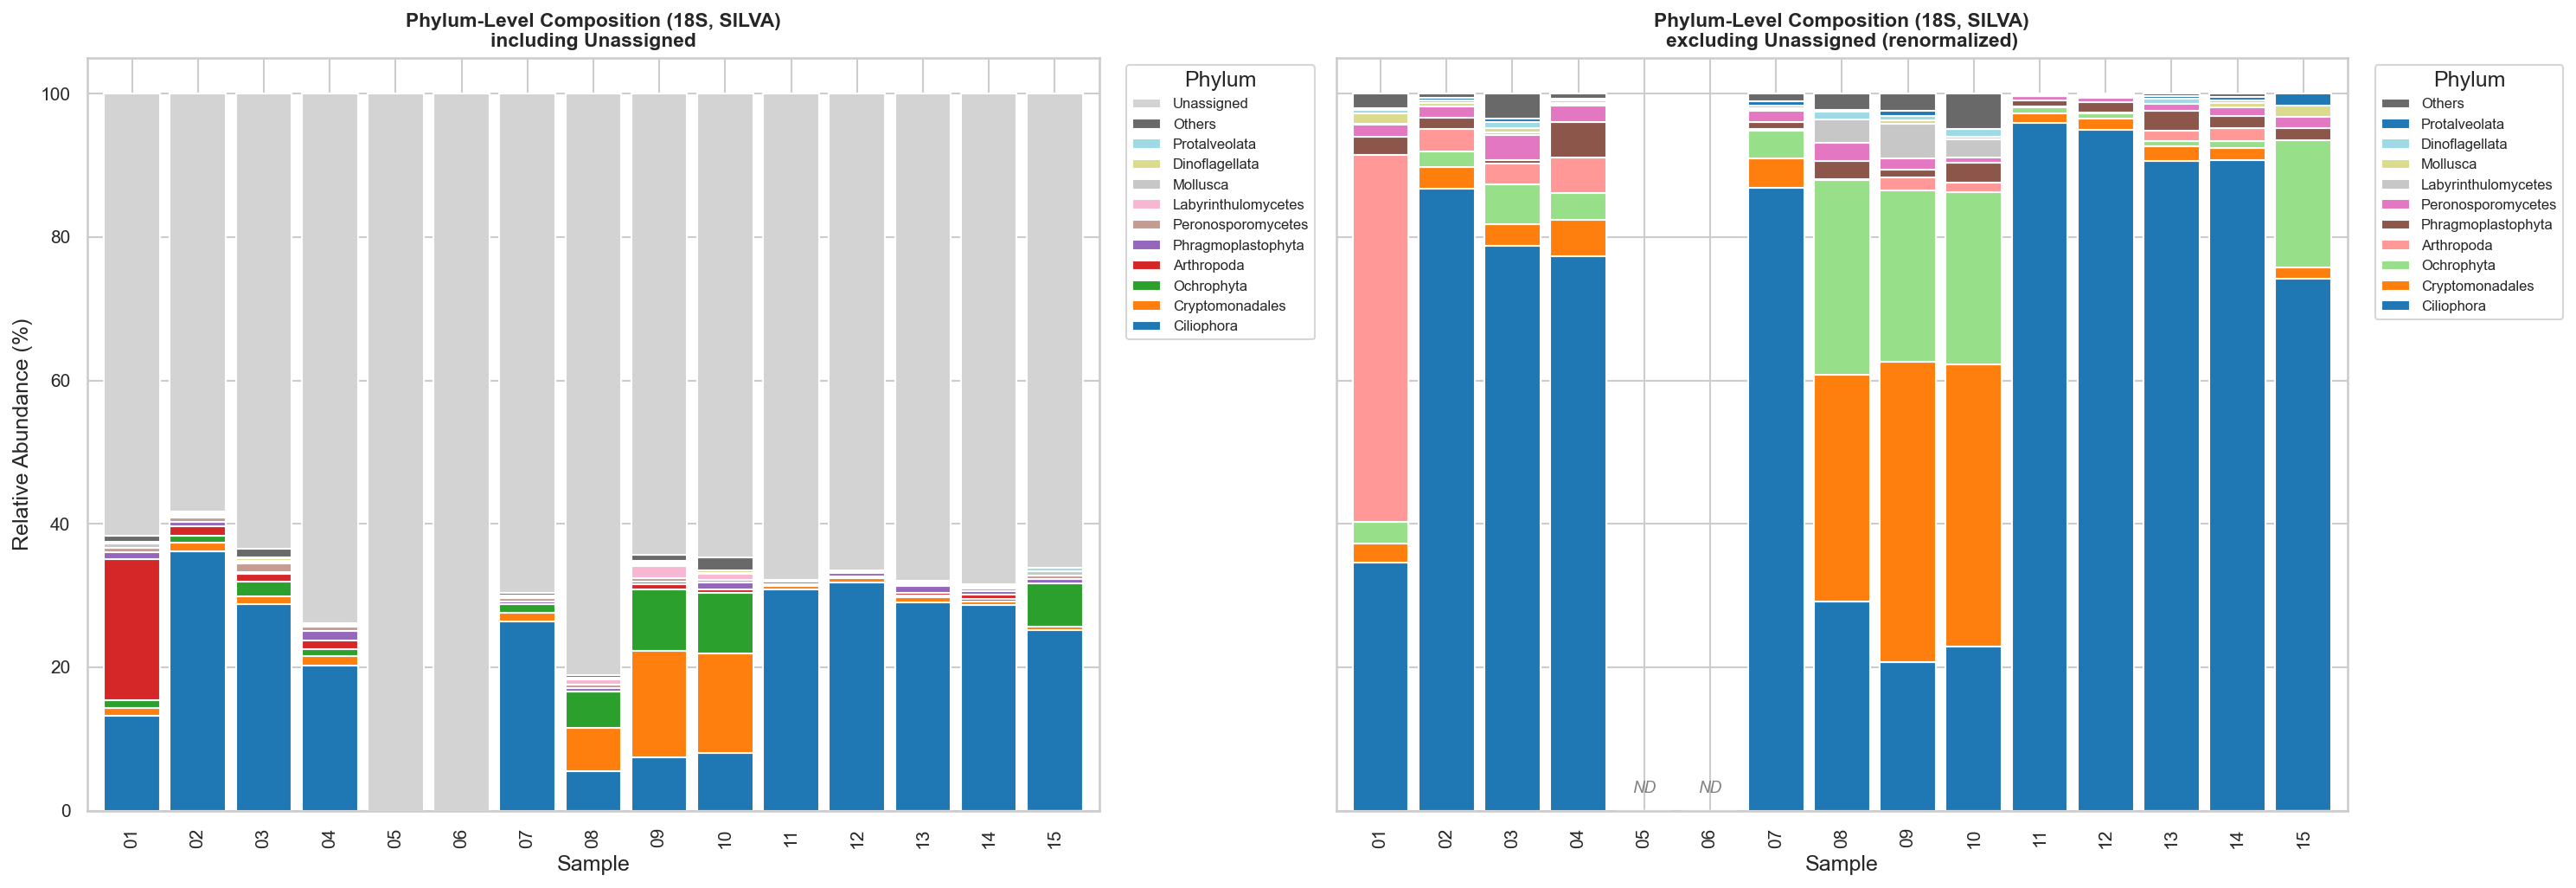

In [7]:
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_18s, 'Phylum', prefix_18s, '18S', sample_cols_18s, top_n=10)


## A.1b Class-Level Breakdown (18S)

[18S] Class: Unassigned = 74.2% of reads


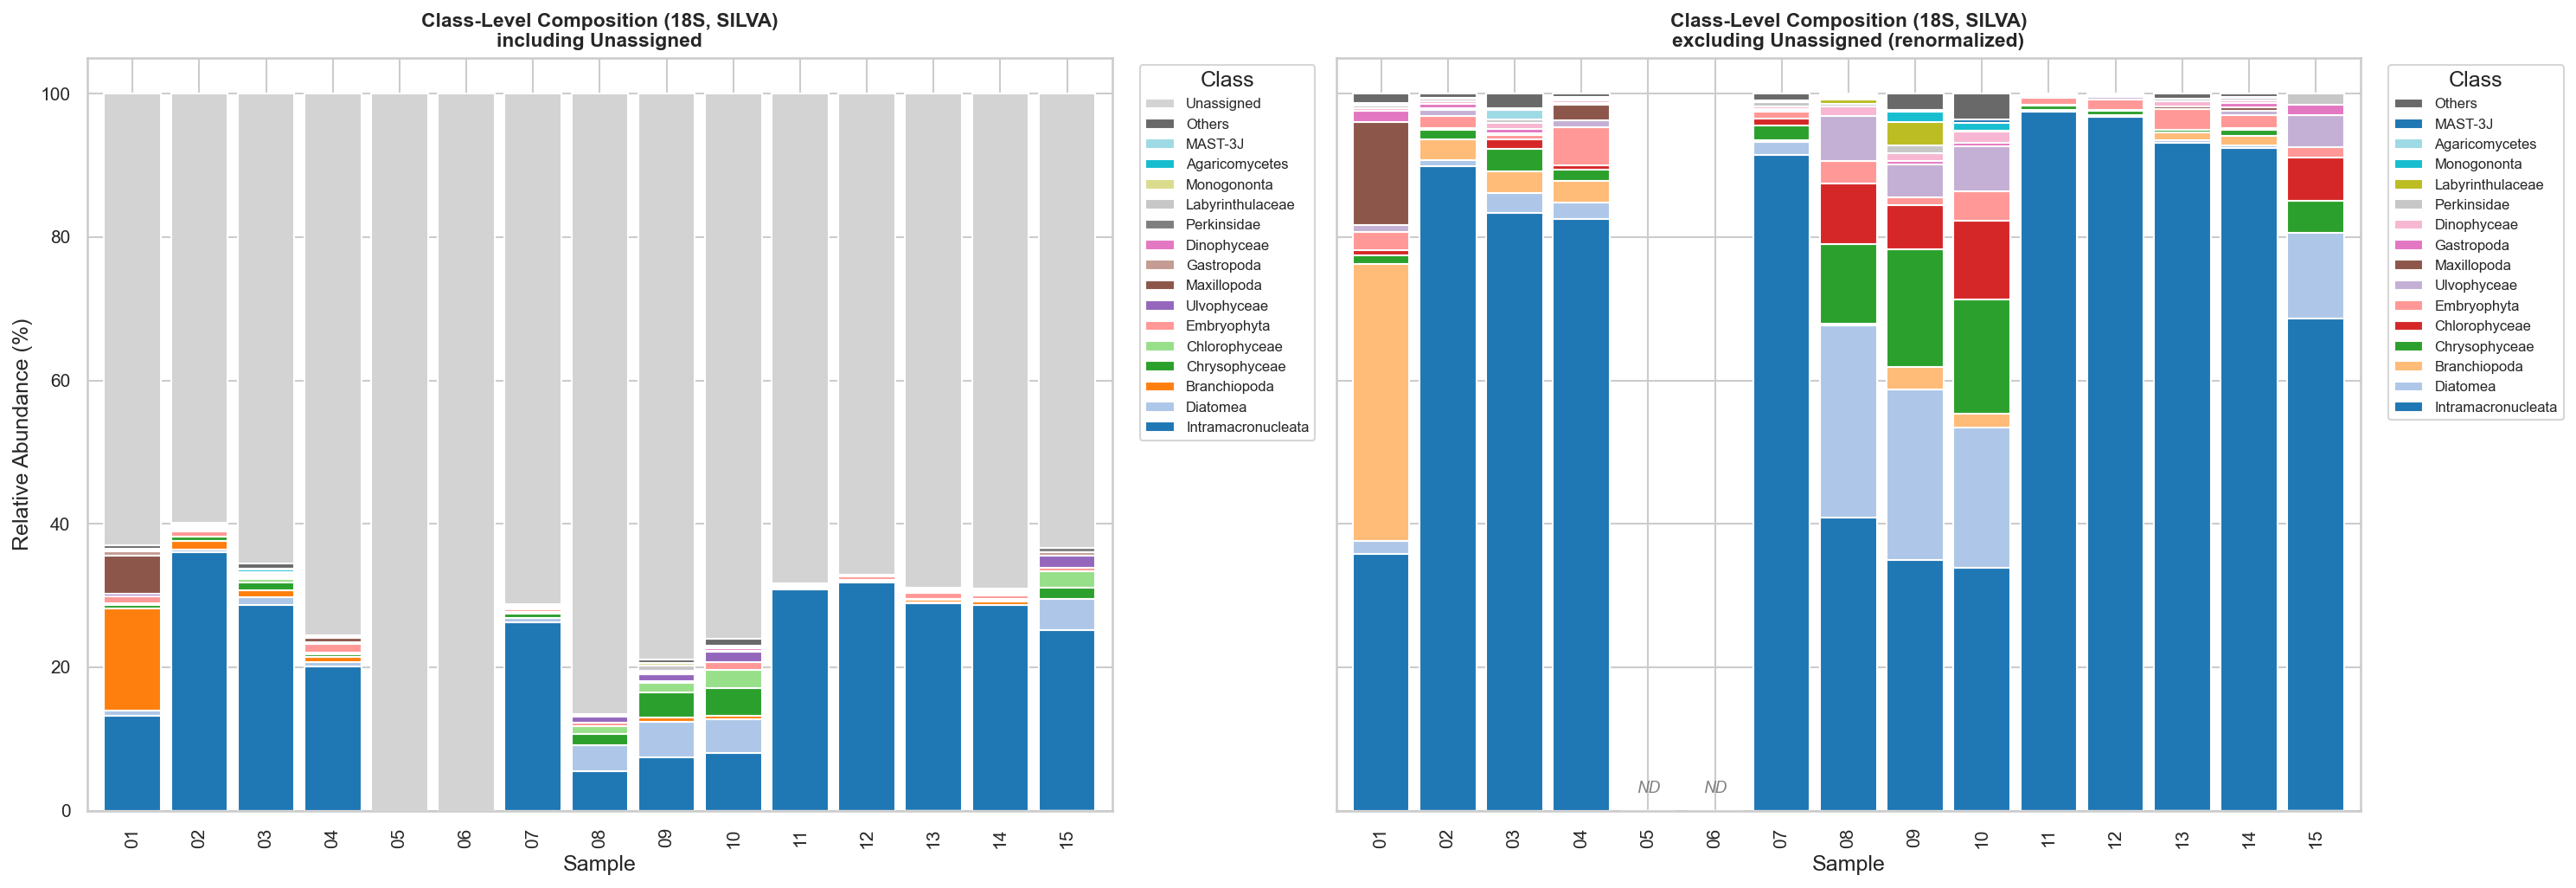

In [8]:
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_18s, 'Class', prefix_18s, '18S', sample_cols_18s, top_n=15)


## A.2 Order-Level Breakdown (18S)

[18S] Order: Unassigned = 76.3% of reads


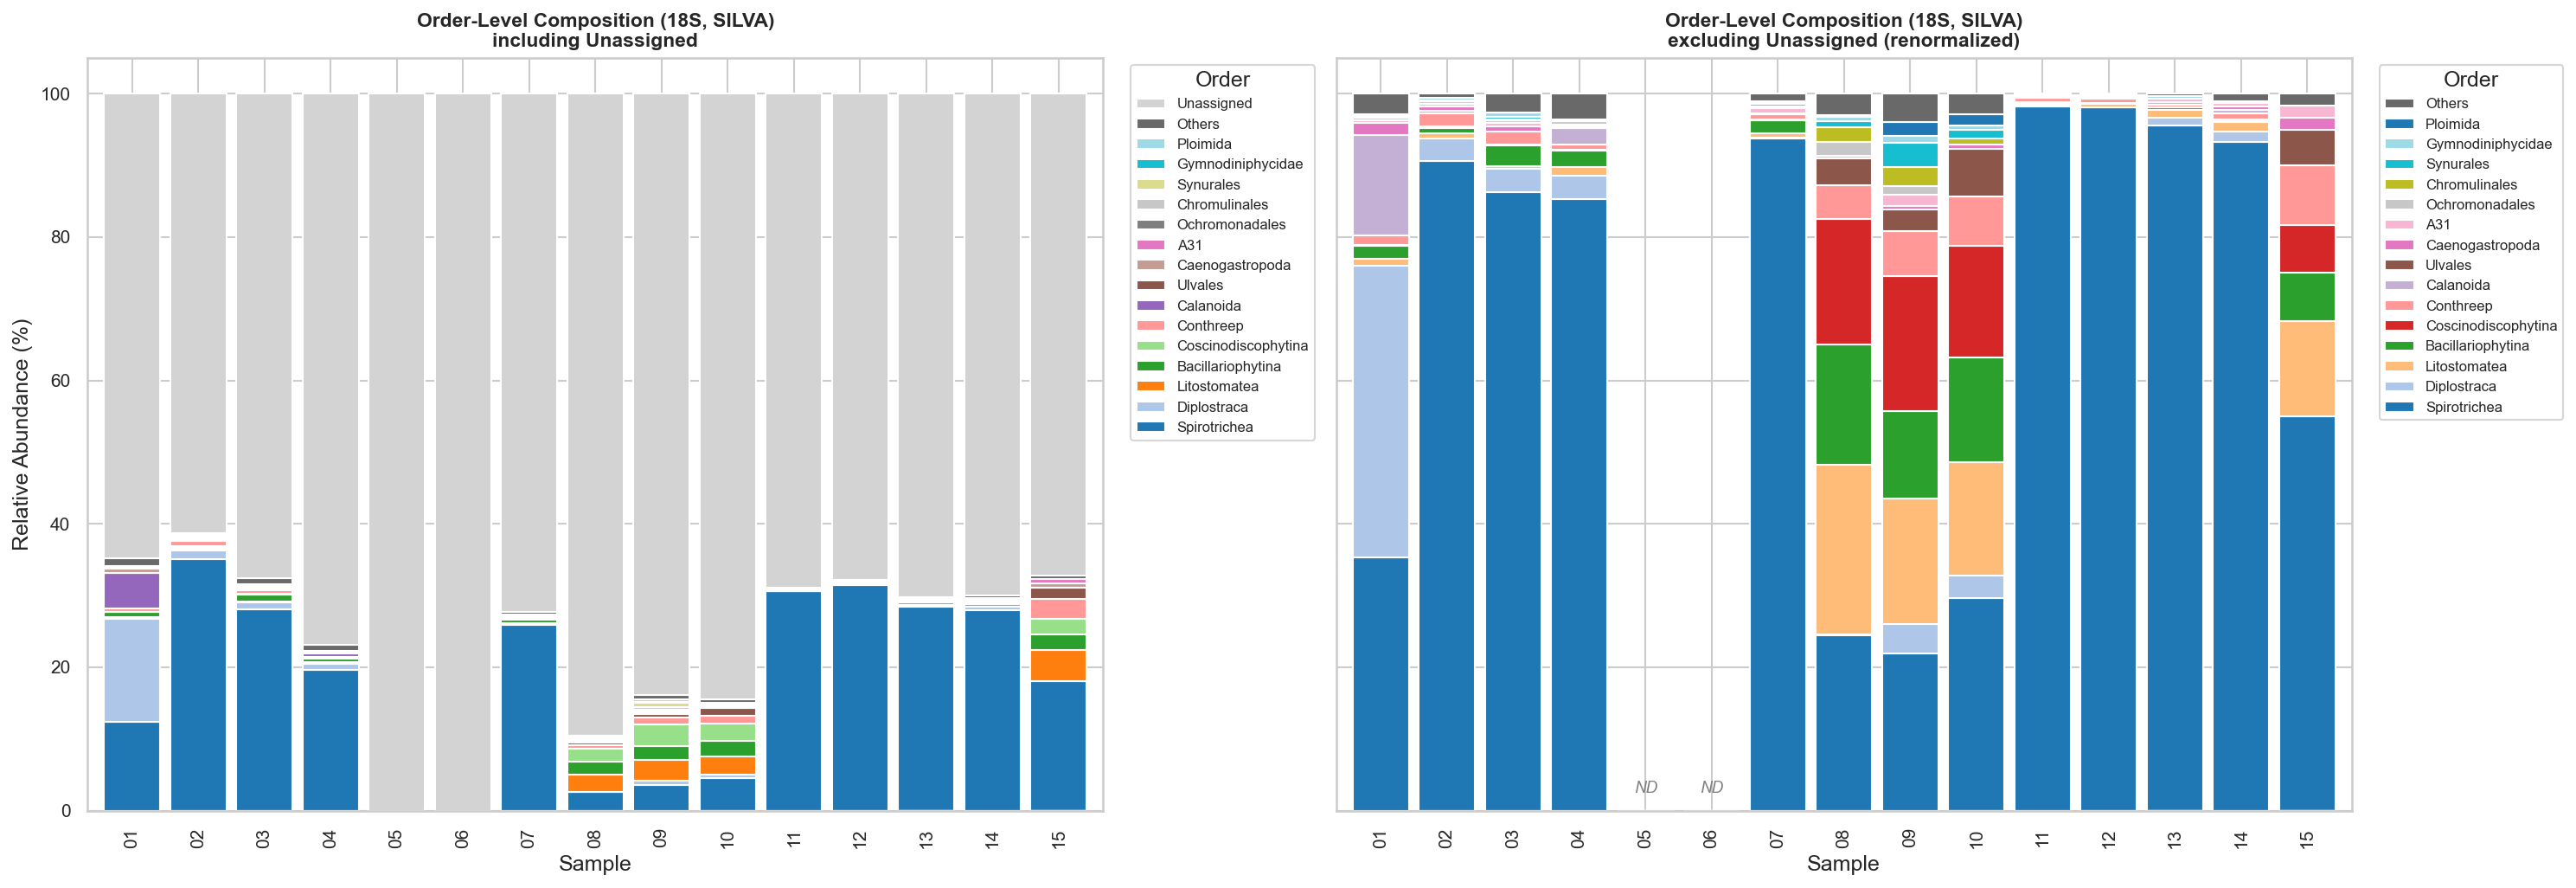

In [9]:
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_18s, 'Order', prefix_18s, '18S', sample_cols_18s, top_n=15)


## A.3 Genus-Level Top 20 (18S)
Top genera detected by the 18S marker with confidence annotations.

C:\Users\ilias\AppData\Local\Temp\ipykernel_34524\1180226389.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)


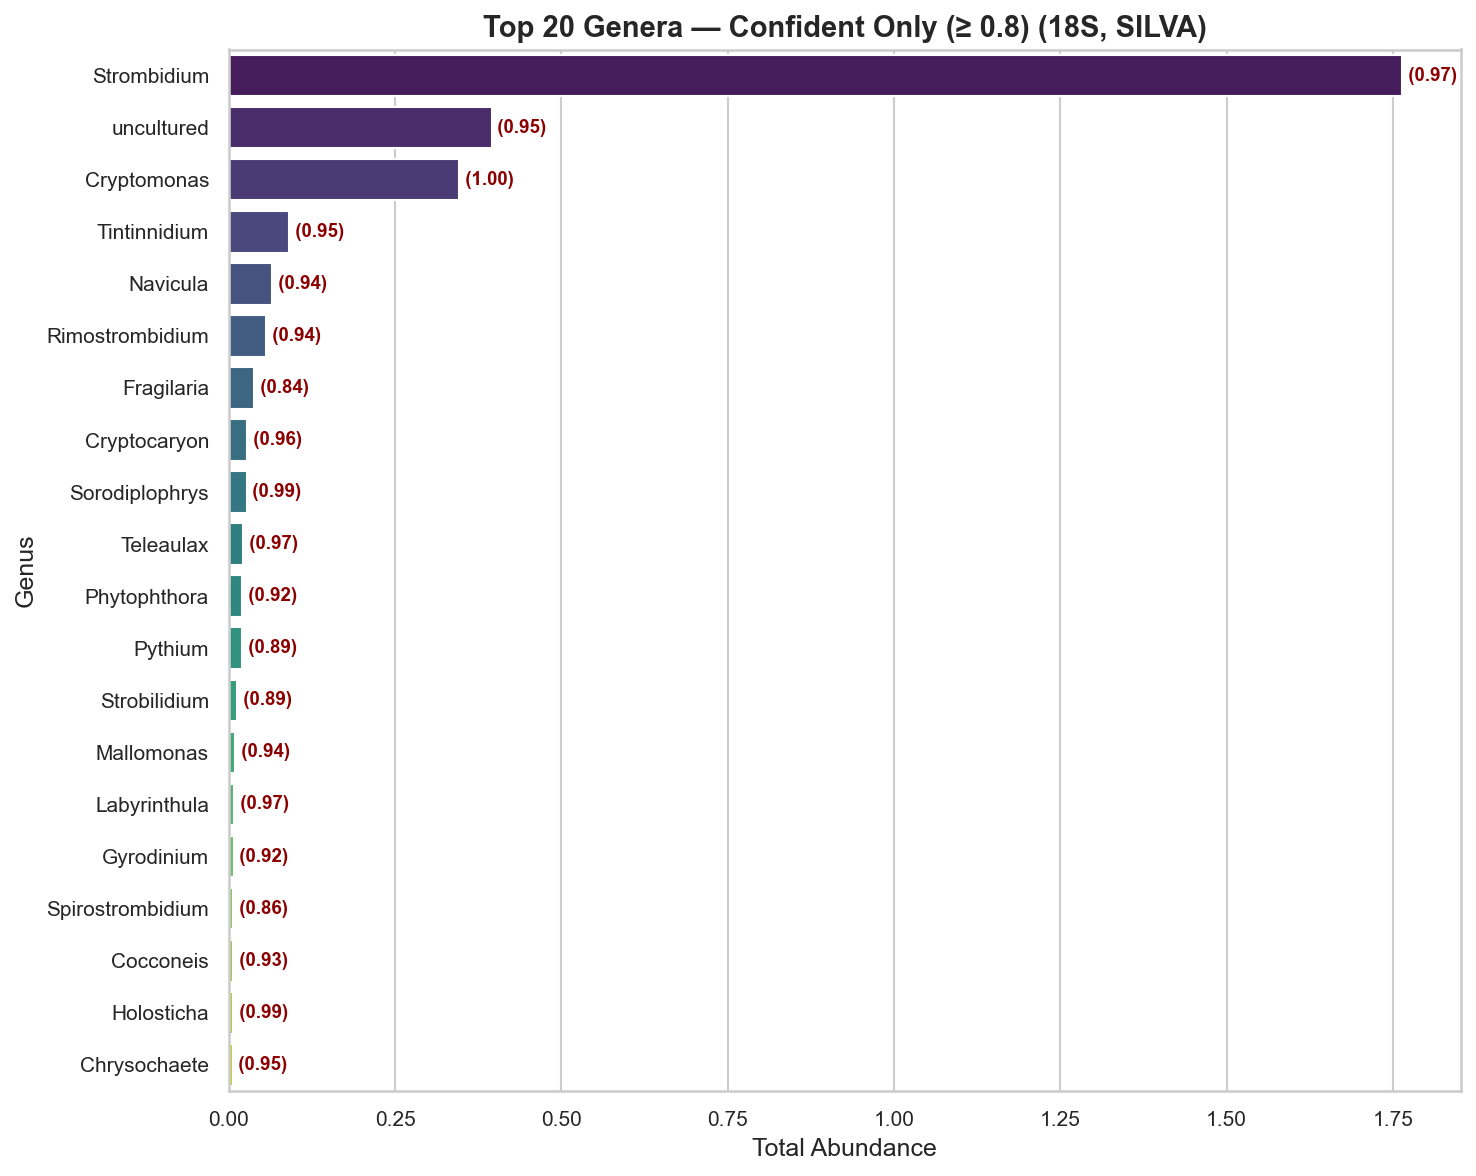

In [10]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_18s[genus_col] = df_18s[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_18s.columns:
    mask_conf = pd.to_numeric(df_18s[conf_col], errors='coerce') >= 0.8
    df_conf = df_18s[mask_conf].copy()
else:
    df_conf = df_18s[df_18s[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_18s].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.sum(axis=1)
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (18S, {prefix_18s})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

### Top 20 Genera by Abundance — All Confidences (18S)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

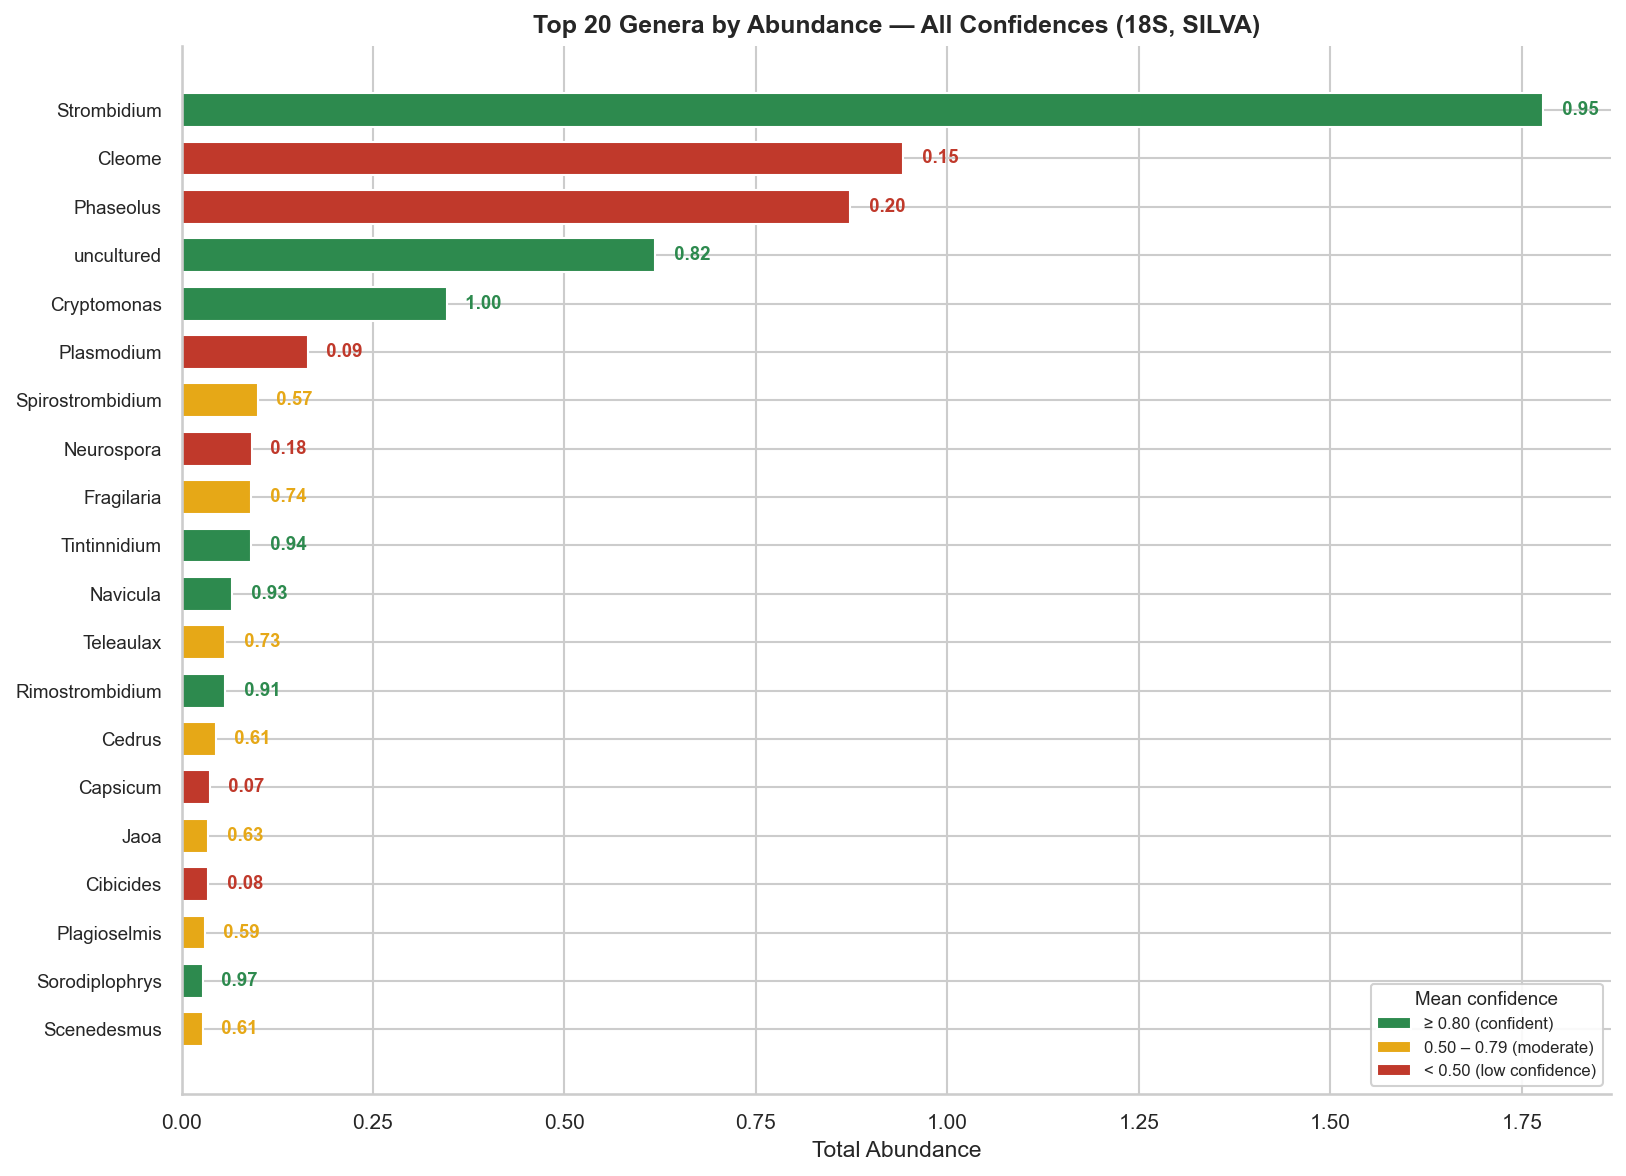

In [11]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_tmp = df_18s.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_18s].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.sum(axis=1)
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Total Abundance', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (18S, {prefix_18s})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
add_conf_note(kind='unfiltered')
plt.show()

## A.2 Taxonomic Resolution Decay (18S)

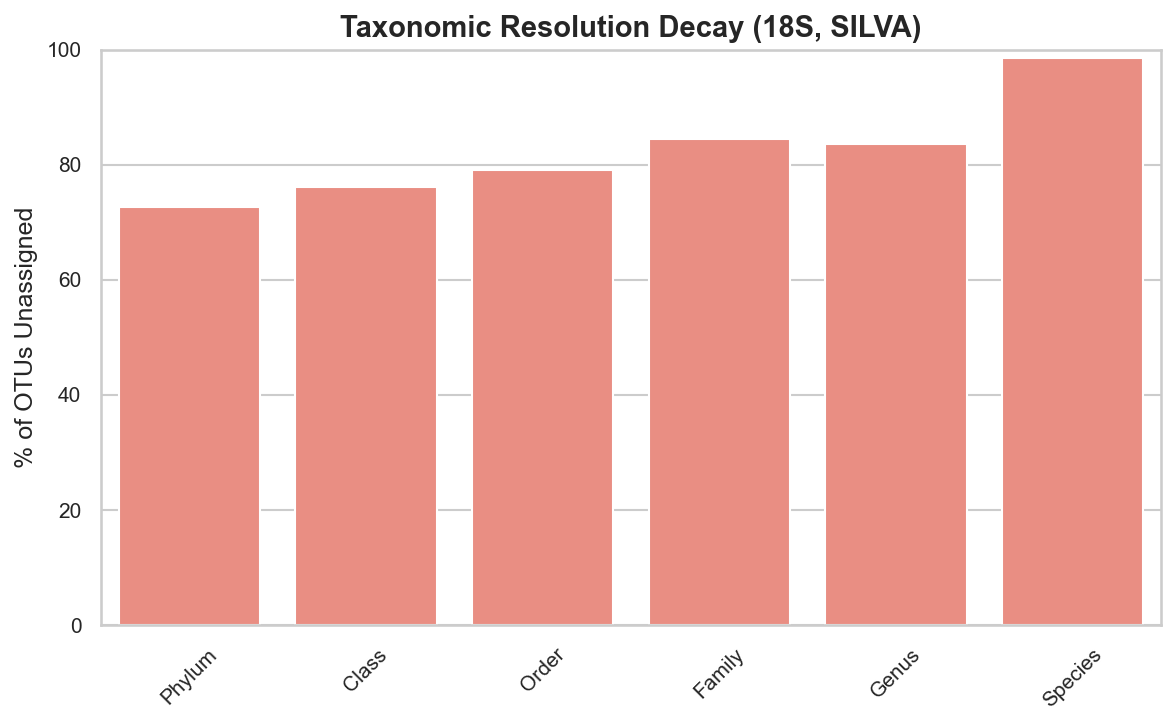

In [12]:
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
levels_18s = [f'{prefix_18s}_{r}' for r in ranks]
unassigned_counts_18s = []

for level in levels_18s:
    conf_level = level + '_Conf'
    no_taxonomy = df_18s[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_18s[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_18s.columns else pd.Series(False, index=df_18s.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_counts_18s.append(pct)

plt.figure(figsize=(8, 5))
sns.barplot(x=ranks, y=unassigned_counts_18s, color="salmon")
plt.title(f'Taxonomic Resolution Decay (18S, {prefix_18s})', fontweight='bold')
plt.ylabel('% of OTUs Unassigned')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

---
# Part B: COI Marker Biodiversity Analysis (eKOI)
*Objective: Characterize the metazoan/eukaryotic community using COI with the eKOI PR2 database.*

### Key changes from MIDORI2:
* eKOI taxonomy is cleaner — no NCBI taxon ID artifacts, no rank prefix stripping needed.
* "Phylum" = PR2 Division (Opisthokonta, Stramenopiles, Alveolata)
* "Class" = PR2 Subdivision (Metazoa, Fungi, Apicomplexa)
* Better protist/ciliate coverage should reveal what MIDORI2 missed.

## B.1a Broad Taxonomic Structure (COI, eKOI)

[COI] Phylum: Unassigned = 84.8% of reads


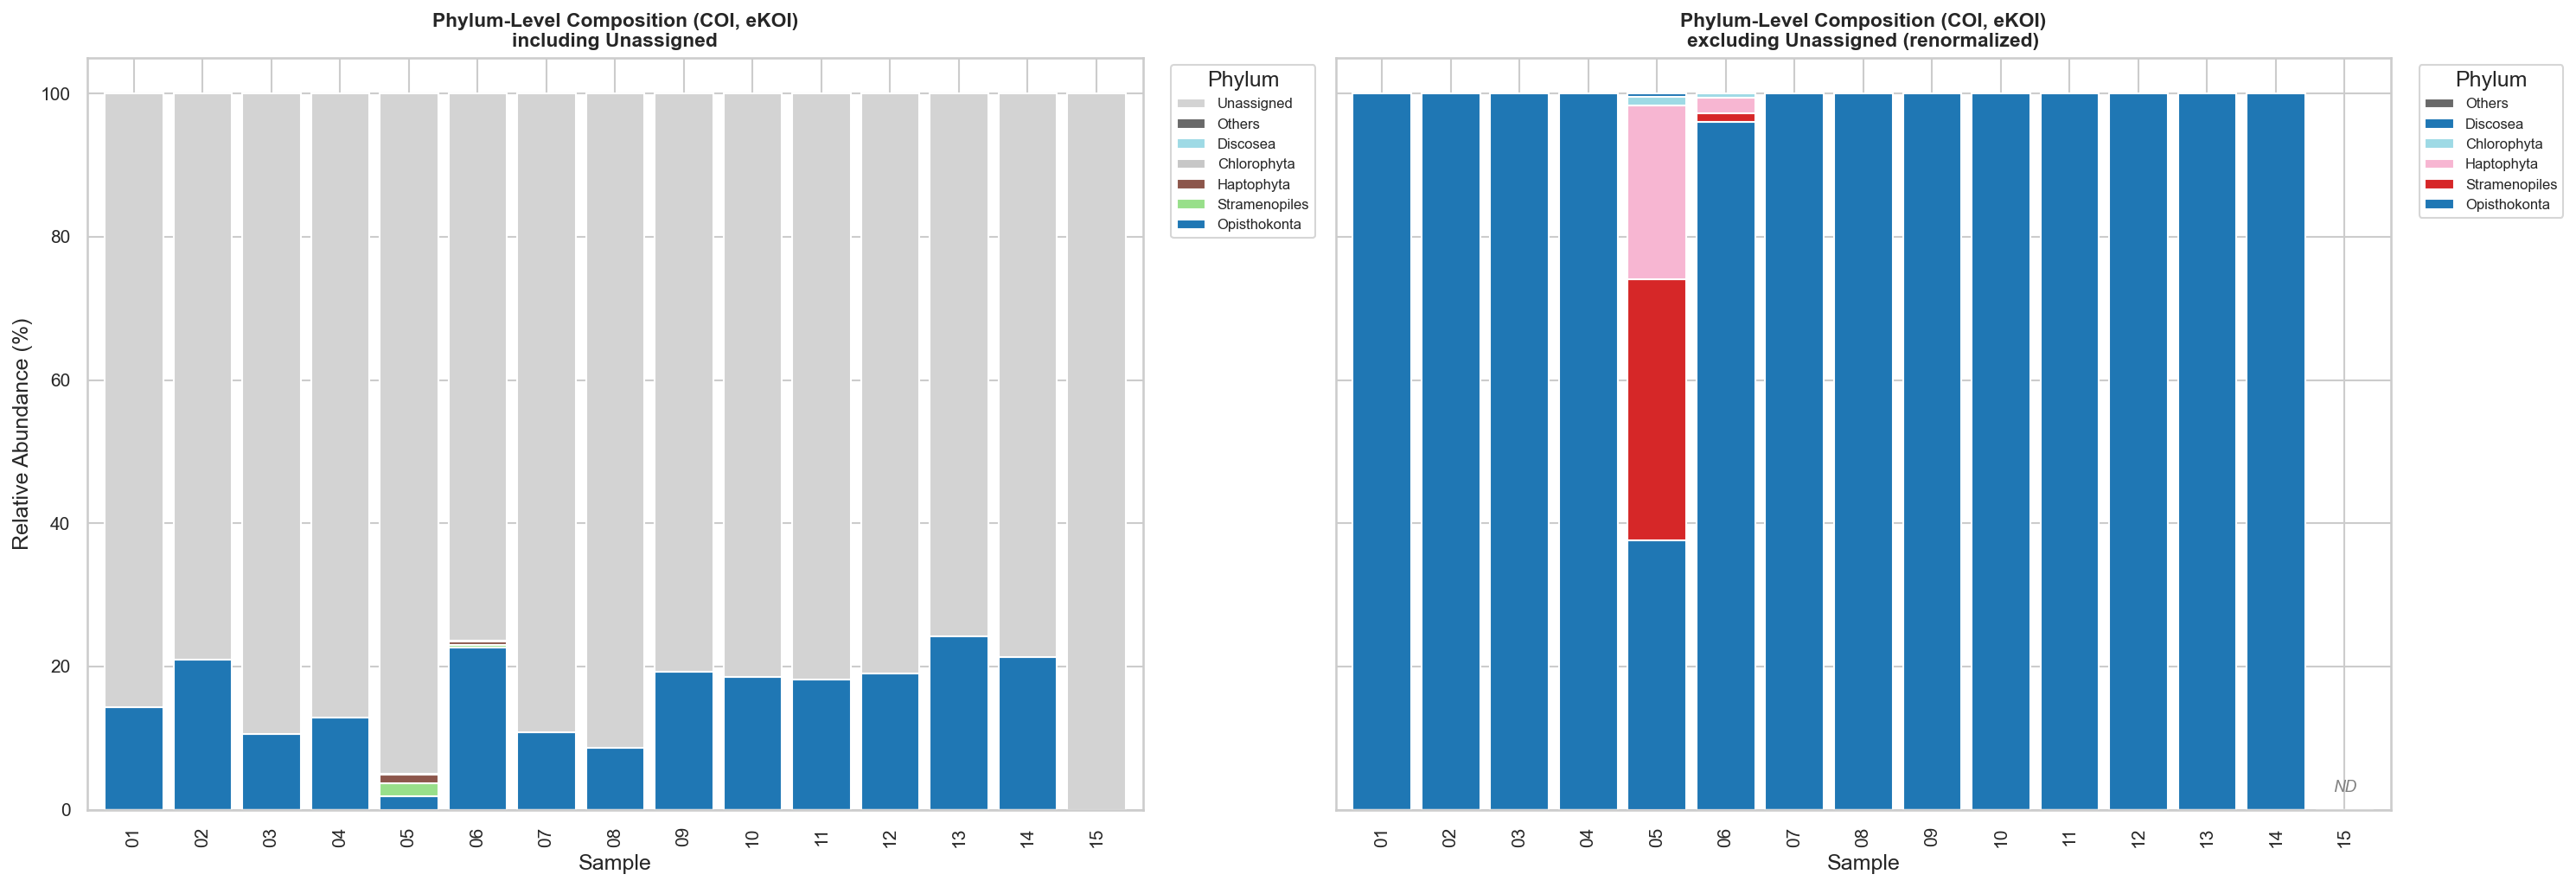

In [13]:
df_coi = df_coi_raw.copy() if "df_coi" not in dir() else df_coi
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_coi, 'Phylum', prefix_coi, 'COI', sample_cols_coi, top_n=10)


## B.1b Class-Level Breakdown (COI, eKOI)
In eKOI, "Class" = PR2 Subdivision. Look for **Metazoa**, **Fungi**, **Apicomplexa**, etc.

[COI] Class: Unassigned = 88.8% of reads


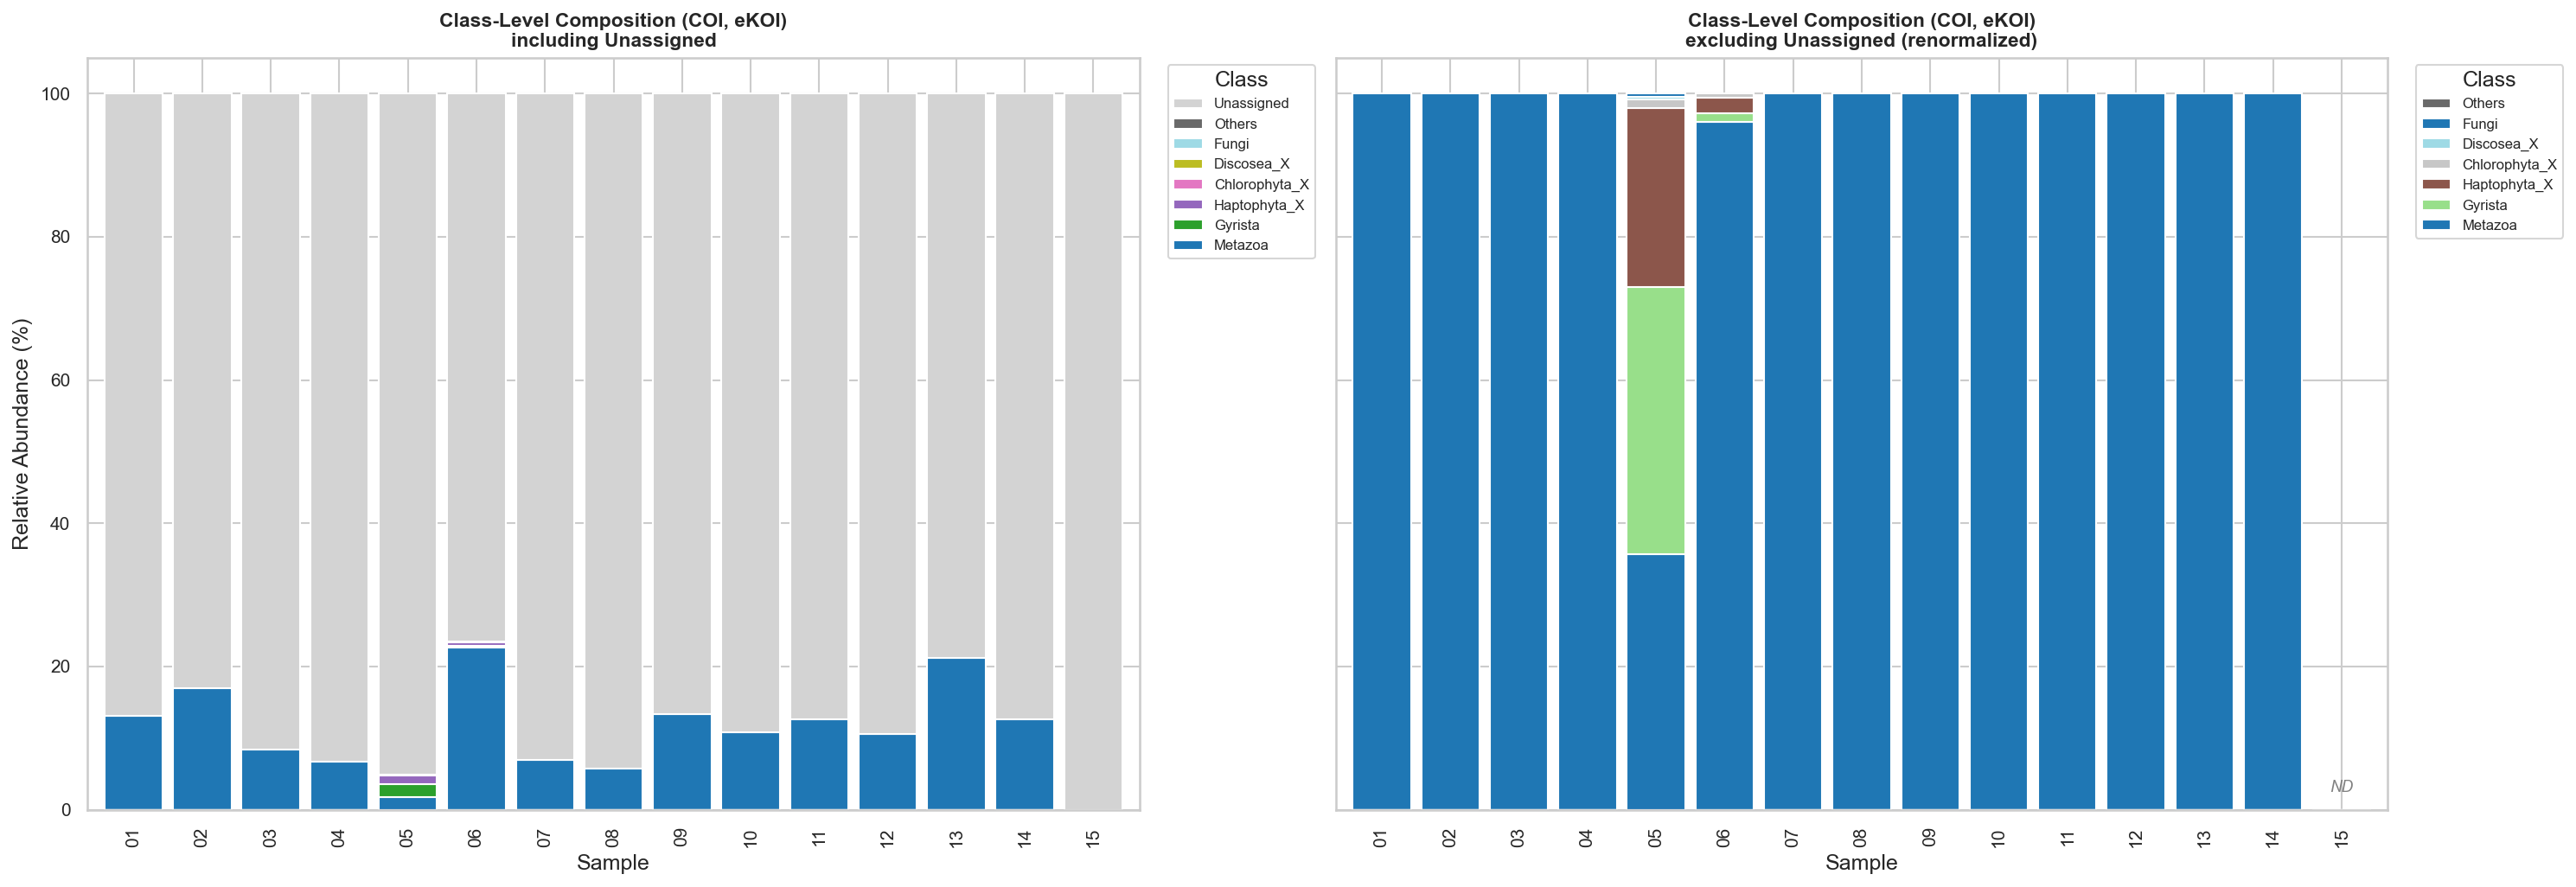

In [14]:
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_coi, 'Class', prefix_coi, 'COI', sample_cols_coi, top_n=15)


## B.2 Order-Level Breakdown (COI, eKOI)
In eKOI, "Order" = PR2 Class level (e.g., Insecta, Teleostei, Mammalia for Metazoa).

[COI] Order: Unassigned = 99.6% of reads


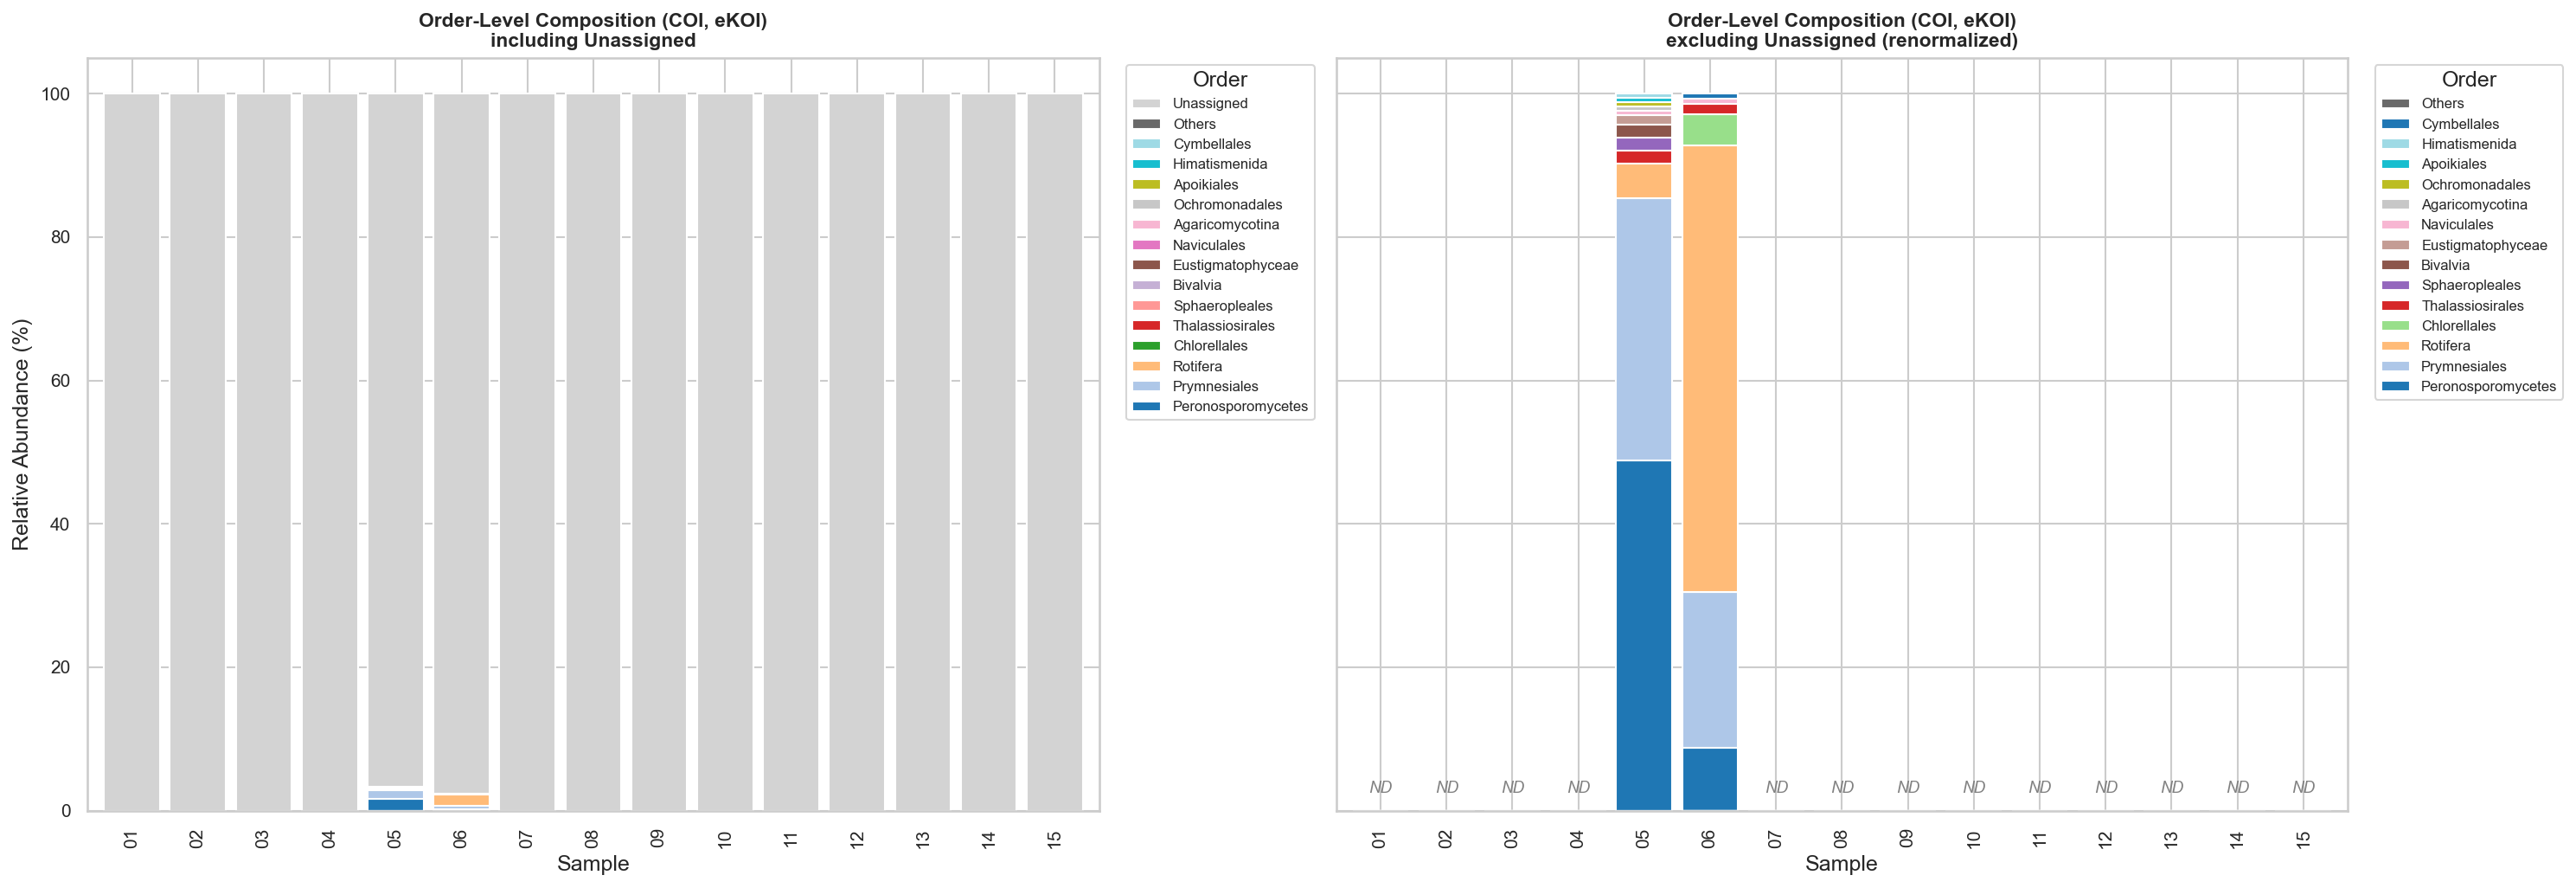

In [15]:
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_coi, 'Order', prefix_coi, 'COI', sample_cols_coi, top_n=15)


## B.3 Genus-Level Top 20 (COI, eKOI)

C:\Users\ilias\AppData\Local\Temp\ipykernel_34524\250747822.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)


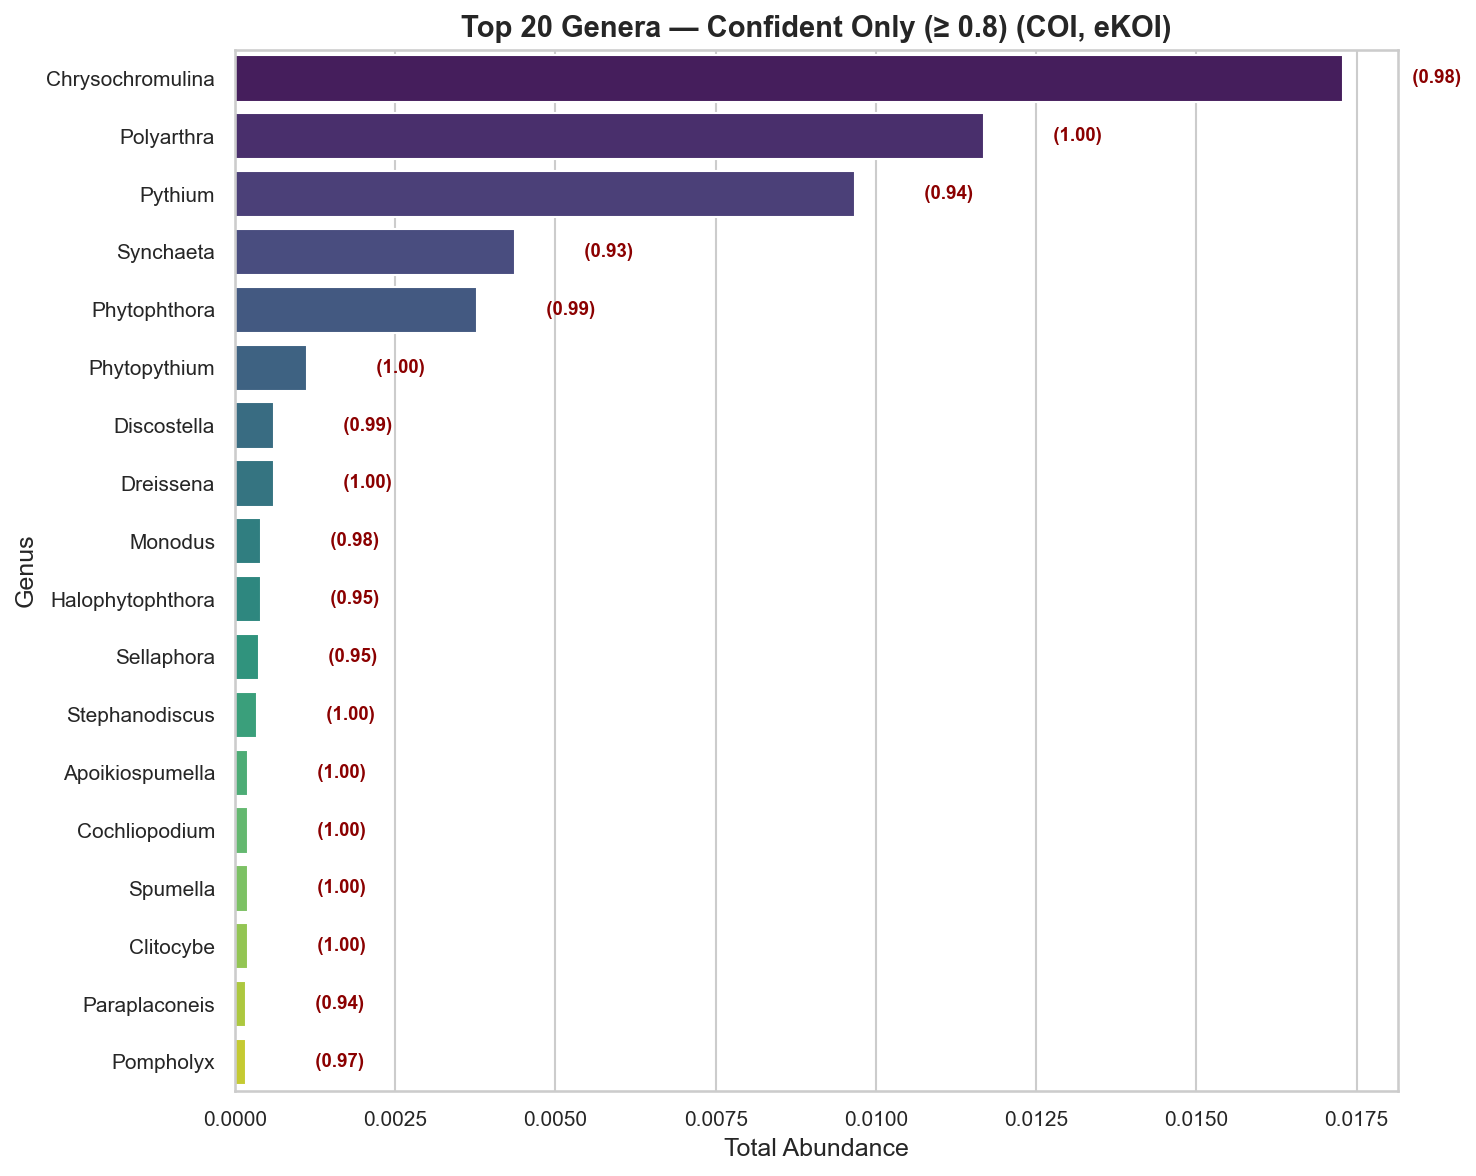

In [16]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_coi[genus_col] = df_coi[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_coi.columns:
    mask_conf = pd.to_numeric(df_coi[conf_col], errors='coerce') >= 0.8
    df_conf = df_coi[mask_conf].copy()
else:
    df_conf = df_coi[df_coi[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_coi].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.sum(axis=1)
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (COI, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

### Top 20 Genera by Abundance — All Confidences (COI)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

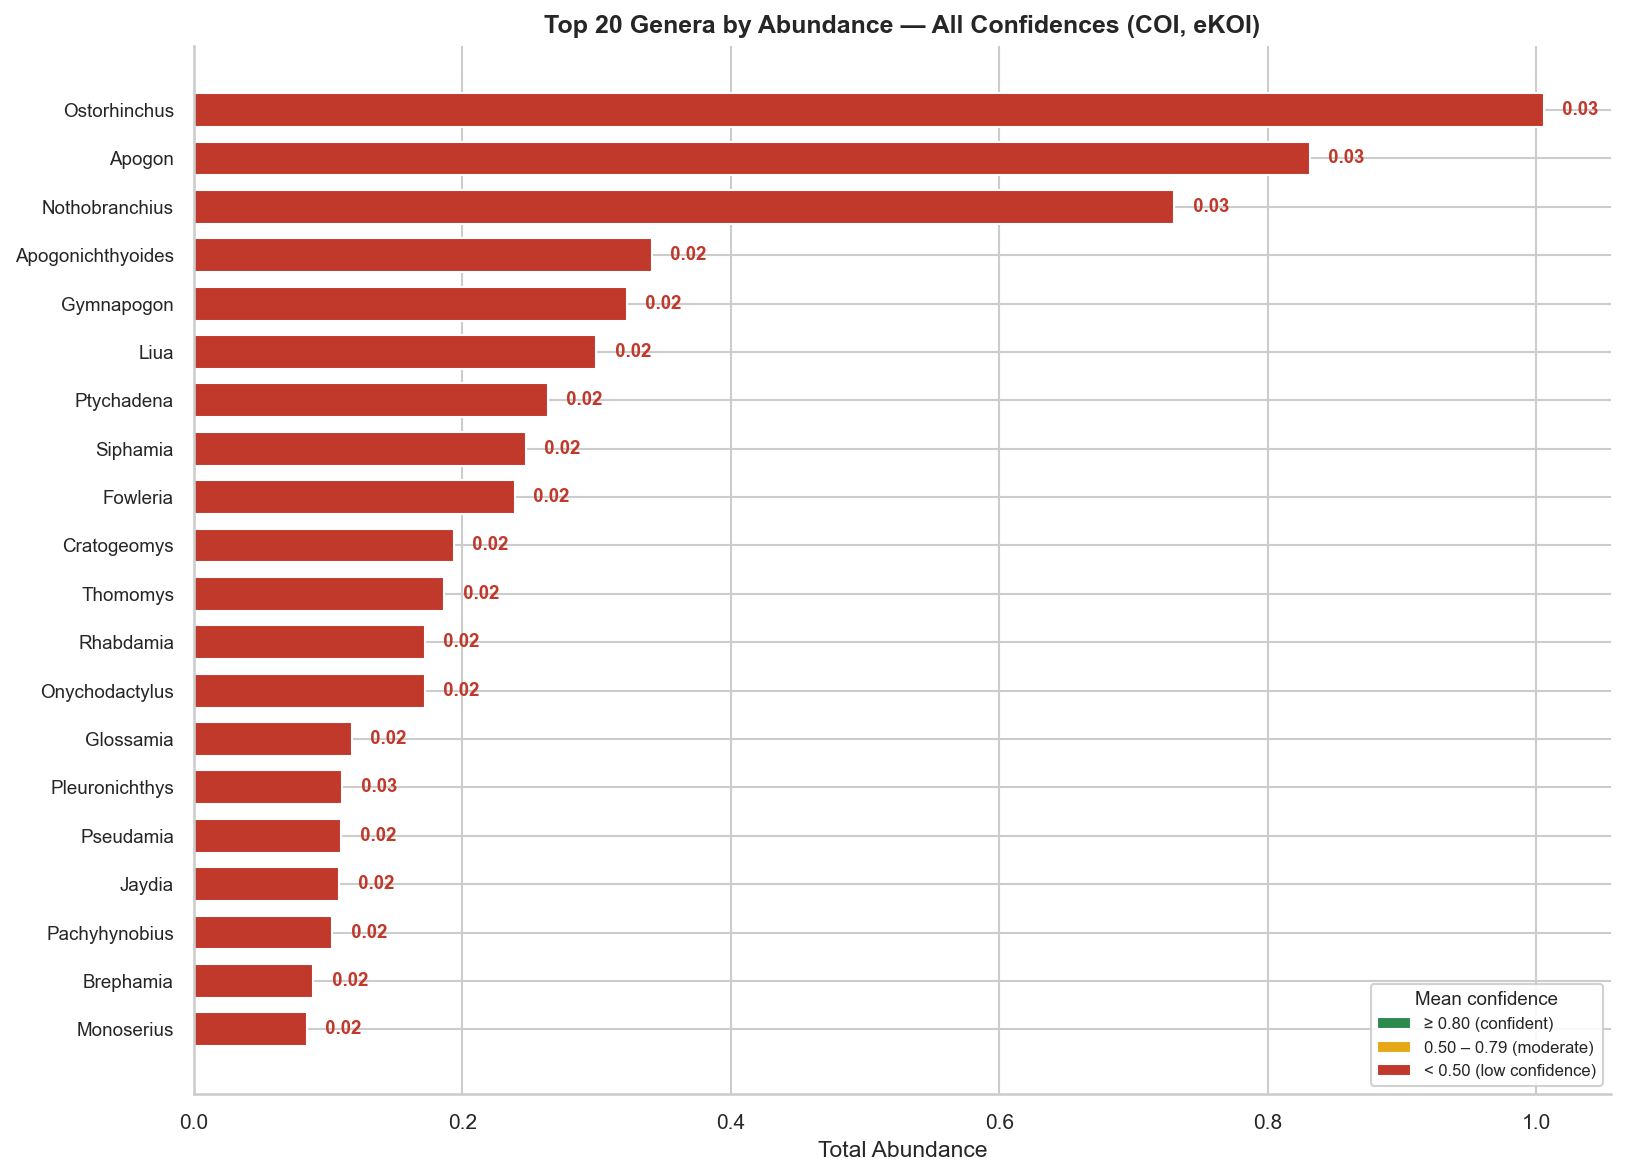

In [17]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_tmp = df_coi.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_coi].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.sum(axis=1)
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Total Abundance', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (COI, {prefix_coi})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
add_conf_note(kind='unfiltered')
plt.show()

## B.4 Taxonomic Resolution Comparison: 18S (SILVA) vs COI (eKOI)

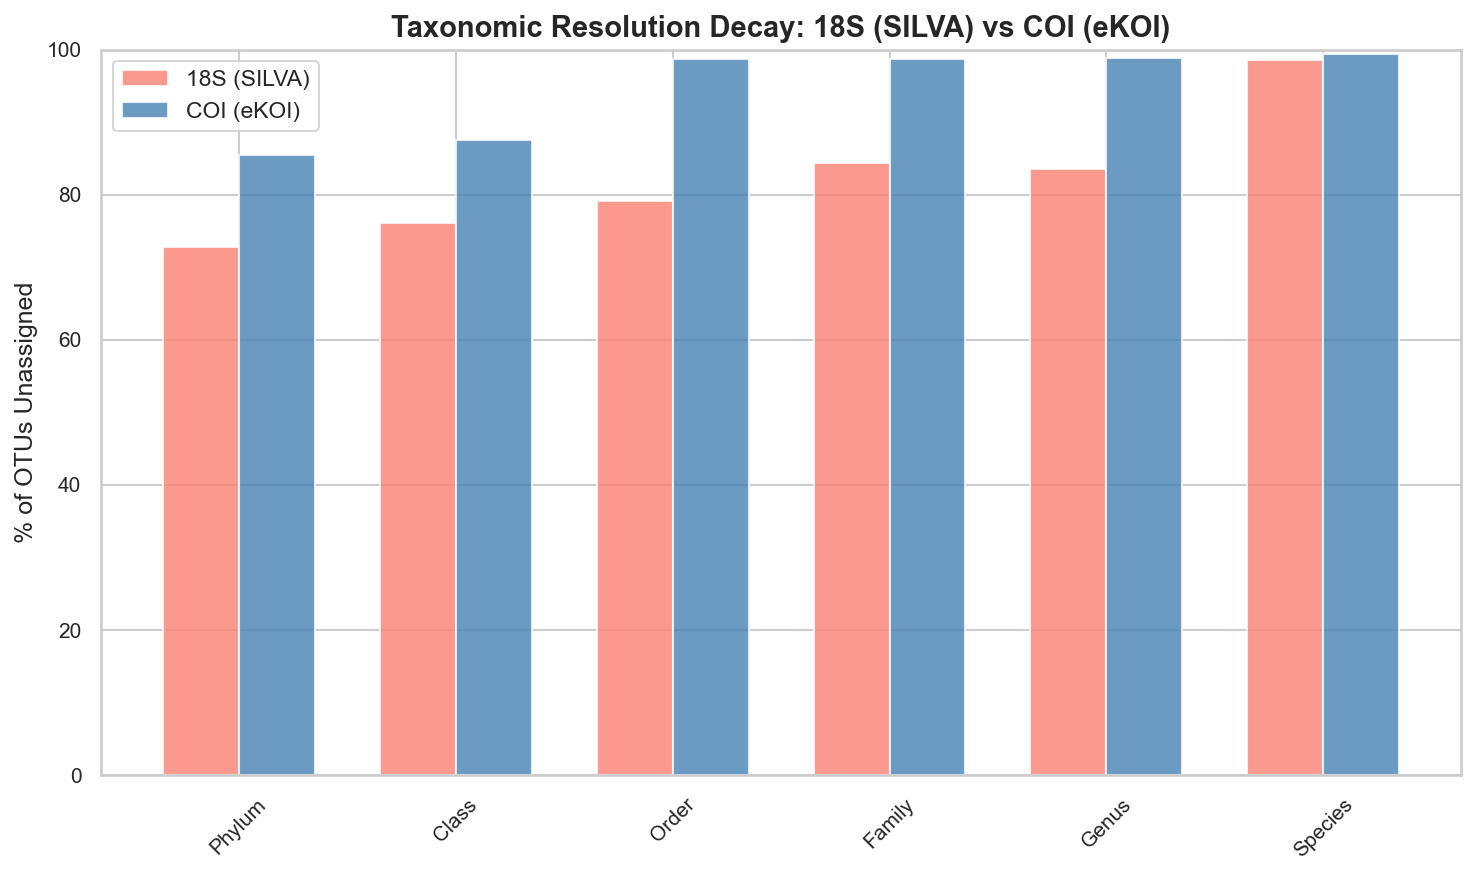

In [18]:
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

levels_18s = [f'{prefix_18s}_{r}' for r in ranks]
unassigned_18s = []
for level in levels_18s:
    conf_level = level + '_Conf'
    no_taxonomy = df_18s[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_18s[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_18s.columns else pd.Series(False, index=df_18s.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_18s.append(pct)

levels_coi = [f'{prefix_coi}_{r}' for r in ranks]
unassigned_coi = []
for level in levels_coi:
    conf_level = level + '_Conf'
    no_taxonomy = df_coi[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_coi[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_coi.columns else pd.Series(False, index=df_coi.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_coi)) * 100
    unassigned_coi.append(pct)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ranks))
width = 0.35

bars1 = ax.bar(x - width/2, unassigned_18s, width, label=f'18S ({prefix_18s})', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, unassigned_coi, width, label=f'COI ({prefix_coi})', color='steelblue', alpha=0.8)

ax.set_title('Taxonomic Resolution Decay: 18S (SILVA) vs COI (eKOI)', fontweight='bold')
ax.set_ylabel('% of OTUs Unassigned')
ax.set_xticks(x)
ax.set_xticklabels(ranks, rotation=45)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

## Forensics: BLAST Identification (18S)
BLAST validation of the top 18S OTUs provides ground-truth identification beyond what SINTAX can offer.
Compare these species-level results with the SILVA taxonomy assignments above.

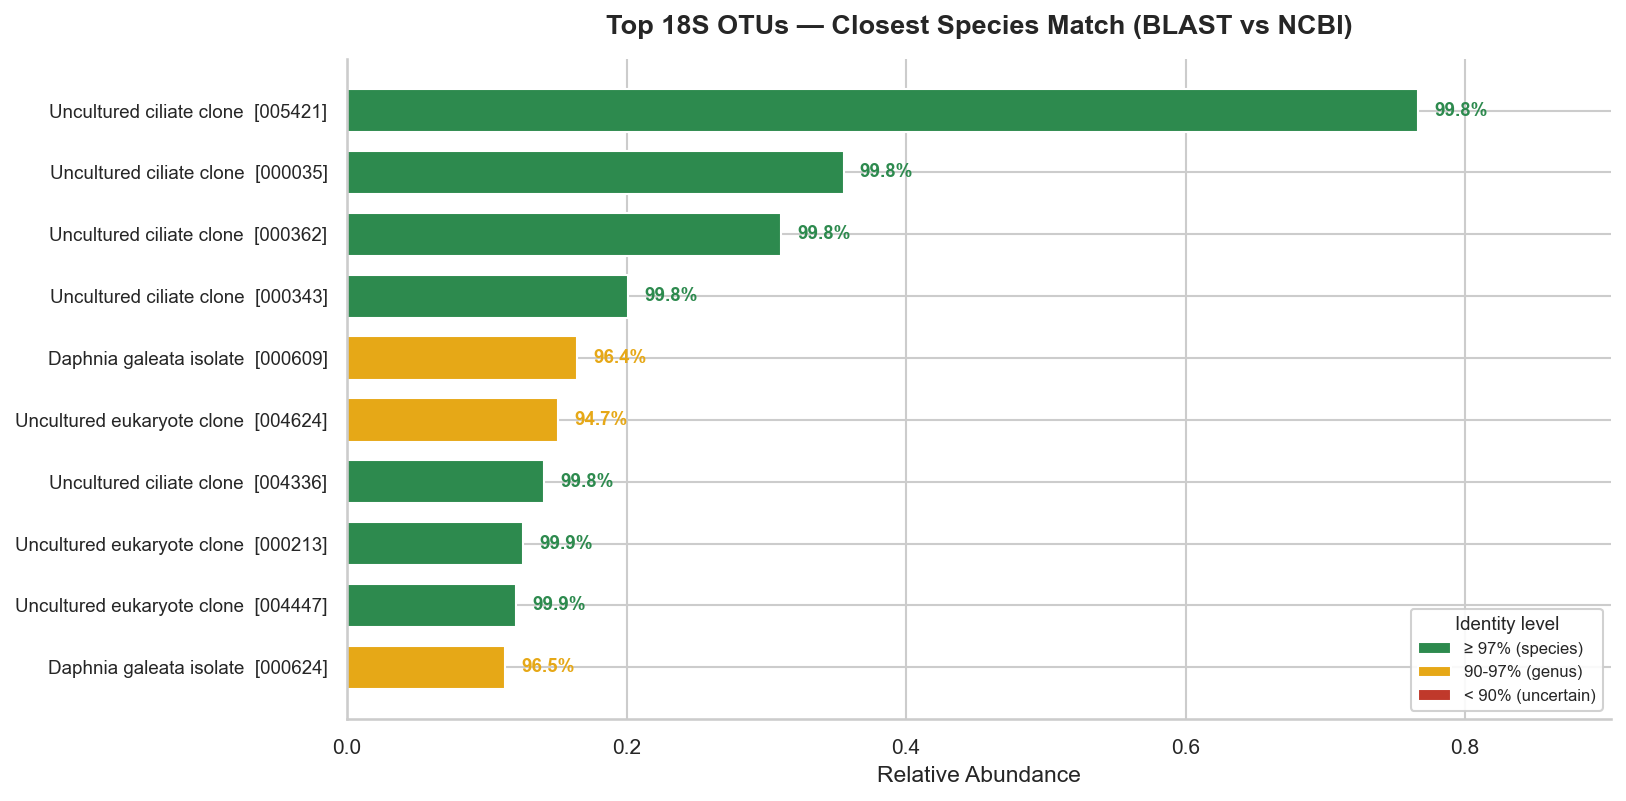

In [19]:
def parse_blast_file(filepath):
    """Parses the custom text output from script 6_blast_top_otus.py"""
    data = []
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        start_reading = False
        for line in lines:
            if line.startswith('---'):
                start_reading = True
                continue
            if not start_reading or not line.strip(): continue
            parts = line.split('|')
            if len(parts) >= 4:
                otu_id = parts[0].strip()
                species = parts[2].strip()
                identity_str = parts[3].strip().replace('%', '')
                try:
                    reads = float(parts[1].strip())
                    identity = float(identity_str) if identity_str and identity_str != '-' else None
                    data.append({'OTU': otu_id, 'Species': species, 'Abundance': reads, 'Identity': identity})
                except: continue
    except FileNotFoundError:
        print("BLAST file not found.")
        return pd.DataFrame()
    return pd.DataFrame(data)

df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_18S.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top 18S OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    add_conf_note(kind='blast')
    plt.show()
else:
    print("No valid BLAST data found to plot.")

## Forensics: BLAST Identification (COI, eKOI)
BLAST validation of the top COI OTUs — compare with the eKOI SINTAX taxonomy above.

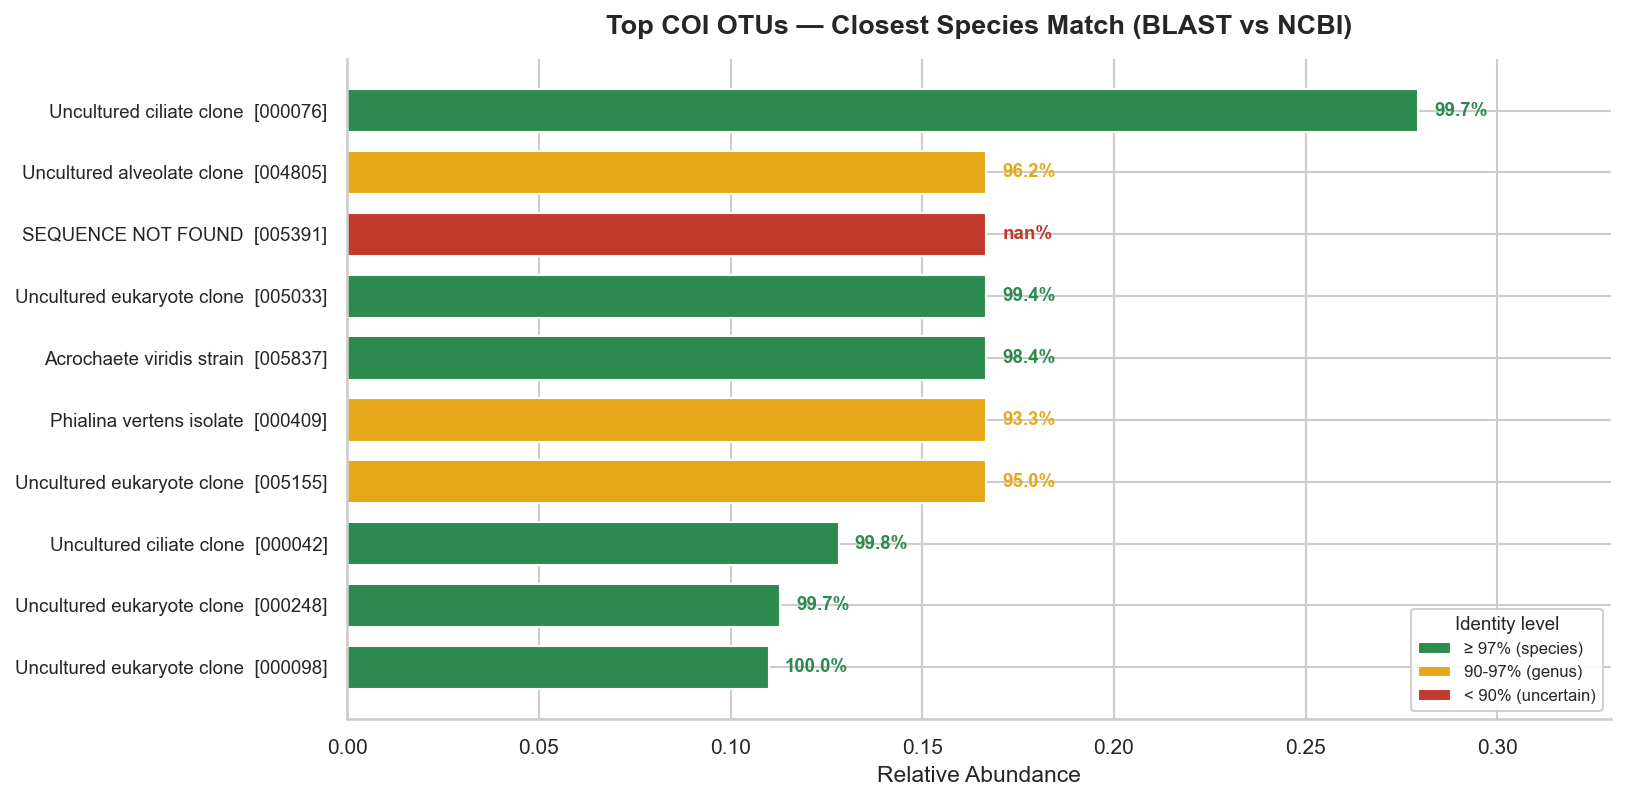

In [20]:
df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_COI.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top COI OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    add_conf_note(kind='blast')
    plt.show()
else:
    print("No valid BLAST data found to plot.")

---
## Part D: Cross-Marker Comparison (18S SILVA vs COI eKOI)
Compare the taxonomic profiles from both markers to identify concordance and unique detections.

In [21]:
# Compare genus-level detections between 18S and COI
genus_col_18s = f'{prefix_18s}_Genus'
genus_col_coi = f'{prefix_coi}_Genus'

# Only include genera with confidence >= threshold
_g_conf_18s = f'{prefix_18s}_Genus_Conf'
if _g_conf_18s in df_18s.columns:
    _mask_18s = pd.to_numeric(df_18s[_g_conf_18s], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_18s_g = df_18s[_mask_18s]
else:
    _df_18s_g = df_18s
genera_18s = set(_df_18s_g[genus_col_18s].dropna().unique()) - {'Unassigned', ''}
_g_conf_coi = f'{prefix_coi}_Genus_Conf'
if _g_conf_coi in df_coi.columns:
    _mask_coi = pd.to_numeric(df_coi[_g_conf_coi], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_coi_g = df_coi[_mask_coi]
else:
    _df_coi_g = df_coi
genera_coi = set(_df_coi_g[genus_col_coi].dropna().unique()) - {'Unassigned', ''}  

shared = genera_18s & genera_coi
only_18s = genera_18s - genera_coi
only_coi = genera_coi - genera_18s

print(f"Genera detected by 18S (SILVA): {len(genera_18s)}")
print(f"Genera detected by COI (eKOI):  {len(genera_coi)}")
print(f"Shared genera:                  {len(shared)}")
print(f"Only in 18S:                    {len(only_18s)}")
print(f"Only in COI:                    {len(only_coi)}")

if shared:
    print(f"\nShared genera (first 20): {sorted(shared)[:20]}")

Genera detected by 18S (SILVA): 137
Genera detected by COI (eKOI):  18
Shared genera:                  5
Only in 18S:                    132
Only in COI:                    13

Shared genera (first 20): ['Chrysochromulina', 'Phytophthora', 'Pythium', 'Sellaphora', 'Spumella']
